In [238]:
# This R environment comes with many helpful analytics packages installed
# It is defined by the kaggle/rstats Docker image: https://github.com/kaggle/docker-rstats
# For example, here's a helpful package to load

library(tidyverse) # metapackage of all tidyverse packages

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

list.files(path = "../input")

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

[1] "datasets"

📌 **This notebook is a notebook for the practice of using LSTM to predict risk.**   
📌 **It focused on moving average and risk analysis.**

# **Table of Contents**
✅ **Load Libraries.**   
✅ **Data Load & EDA.**   
✅ **Data Transform.**   
✅ **Data Visulaization.**   
✅ **ML & Risk Analysis.**   

# **Load Libraries**

In [239]:
library(tidymodels)
library(tidyverse)
library(dplyr)
library(ggplot2)
library(gridExtra)
library(psych)
library(ggcorrplot)
library(GGally)
library(lubridate)

# **Data Load & EDA.**

In [240]:
df <- read.csv('/kaggle/input/datasets/nilesh2042/suzuki-stock-data/suzuki_stock_data.csv') %>% janitor::clean_names()

### **Description**

This dataset contains historical stock price data of Suzuki Motor Corporation, listed on the Tokyo Stock Exchange under the ticker 7269.T.    
The data is sourced using the Yahoo Finance API via the yfinance Python library.   

It provides daily trading information useful for financial analysis, time-series modeling, and machine learning applications.  

[Data Link](https://www.kaggle.com/datasets/nilesh2042/suzuki-stock-data/data) <<<

### **Summary**

In [241]:
glimpse(df)

Rows: 2,776
Columns: 6
$ date   <chr> "1/5/2015", "1/6/2015", "1/7/2015", "1/8/2015", "1/9/2015", "1/…
$ close  <dbl> 734.7776, 707.9432, 728.5300, 750.4482, 743.8934, 739.7964, 725…
$ high   <dbl> 747.1707, 721.7702, 732.3196, 755.5694, 757.4132, 742.9715, 739…
$ low    <dbl> 728.0178, 707.0214, 702.8220, 733.6510, 740.4111, 724.7403, 723…
$ open   <dbl> 745.6344, 715.7273, 705.5874, 737.7479, 755.6720, 729.5542, 729…
$ volume <int> 7380400, 11456000, 10361600, 10652000, 11038800, 4946800, 63540…


In [242]:
skim_df <- skimr::skim(df)
print(skim_df)

── Data Summary ────────────────────────
                           Values
Name                       df    
Number of rows             2776  
Number of columns          6     
_______________________          
Column type frequency:           
  character                1     
  numeric                  5     
________________________         
Group variables            None  

── Variable type: character ────────────────────────────────────────────────────
  skim_variable n_missing complete_rate min max empty n_unique whitespace
1 date                  0             1   8  10     0     2776          0

── Variable type: numeric ──────────────────────────────────────────────────────
  skim_variable n_missing complete_rate     mean       sd   p0      p25      p50
1 close                 0             1    1183.     384. 535.     924.    1107.
2 high                  0             1    1197.     389. 554.     932.    1118.
3 low                   0             1    1170.     380. 509.  

### **Checking Missing Value & Duplicate Value**

In [243]:
na <- data.frame(Na_Count = colSums(is.na(df)))
na

,Na_Count
,<dbl>
date,0
close,0
high,0
low,0
open,0
volume,0


In [244]:
sum(duplicated(df))

[1] 0

In [245]:
head(df)

,date,close,high,low,open,volume
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
1,1/5/2015,734.7776,747.1707,728.0178,745.6344,7380400
2,1/6/2015,707.9432,721.7702,707.0214,715.7273,11456000
3,1/7/2015,728.5300,732.3196,702.8220,705.5874,10361600
4,1/8/2015,750.4482,755.5694,733.6510,737.7479,10652000
5,1/9/2015,743.8934,757.4132,740.4111,755.6720,11038800
6,1/13/2015,739.7964,742.9715,724.7403,729.5542,4946800


# **Data Transform**

In [246]:
#Date Type Conversion
df$date <- as.Date(df$date, format = '%m/%d/%Y')

In [247]:
names(df) <- c('Date','Close','High','Low','Open','Volume')

# **Data Visulization**

In [248]:
options(repr.plot.width = 18.0, repr.plot.height = 13.0)

### **Histogram**

In [249]:
p1 <- ggplot(df, aes(x= Open)) + 
    geom_histogram(fill = 'skyblue',bins = 30, col = 'white') + 
    theme_bw() +
    ggtitle('Open Histogram') + 
    theme(axis.title = element_text(size=15),
    axis.text.x = element_text(size = 15, hjust=1),
    title = element_text(size=15)
    )

p2 <-ggplot(df, aes(x= High)) + geom_histogram(fill = 'blue',bins = 30 , col = 'white') + 
    theme_bw() +
    ggtitle('High Histogram') + 
    theme(axis.title = element_text(size=15),
    axis.text.x = element_text(size = 15, hjust=1),
    title = element_text(size=15)
    )

p3 <-ggplot(df, aes(x= Low)) + geom_histogram(fill = 'orange',bins = 30, col = 'white') +
    theme_bw() +
    ggtitle('Low Histogram') + 
    theme(axis.title = element_text(size=15),
    axis.text.x = element_text(size = 15, hjust=1),
    title = element_text(size=15)
    )

p4 <-ggplot(df, aes(x= Close)) + geom_histogram(fill = 'green',bins = 30, col = 'white' ) + 
    theme_bw() +
    ggtitle('Close Histogram') + 
    theme(axis.title = element_text(size=15),
    axis.text.x = element_text(size = 15, hjust=1),
    title = element_text(size=15)
    )

p5 <-ggplot(df, aes(x= Volume)) + geom_histogram(fill = 'red',bins = 30 ,col = 'white') + 
    theme_bw() +
    ggtitle('Volume Histogram') + 
    theme(axis.title = element_text(size=15),
    axis.text.x = element_text(size = 15, hjust=1),
    title = element_text(size=15)
    )

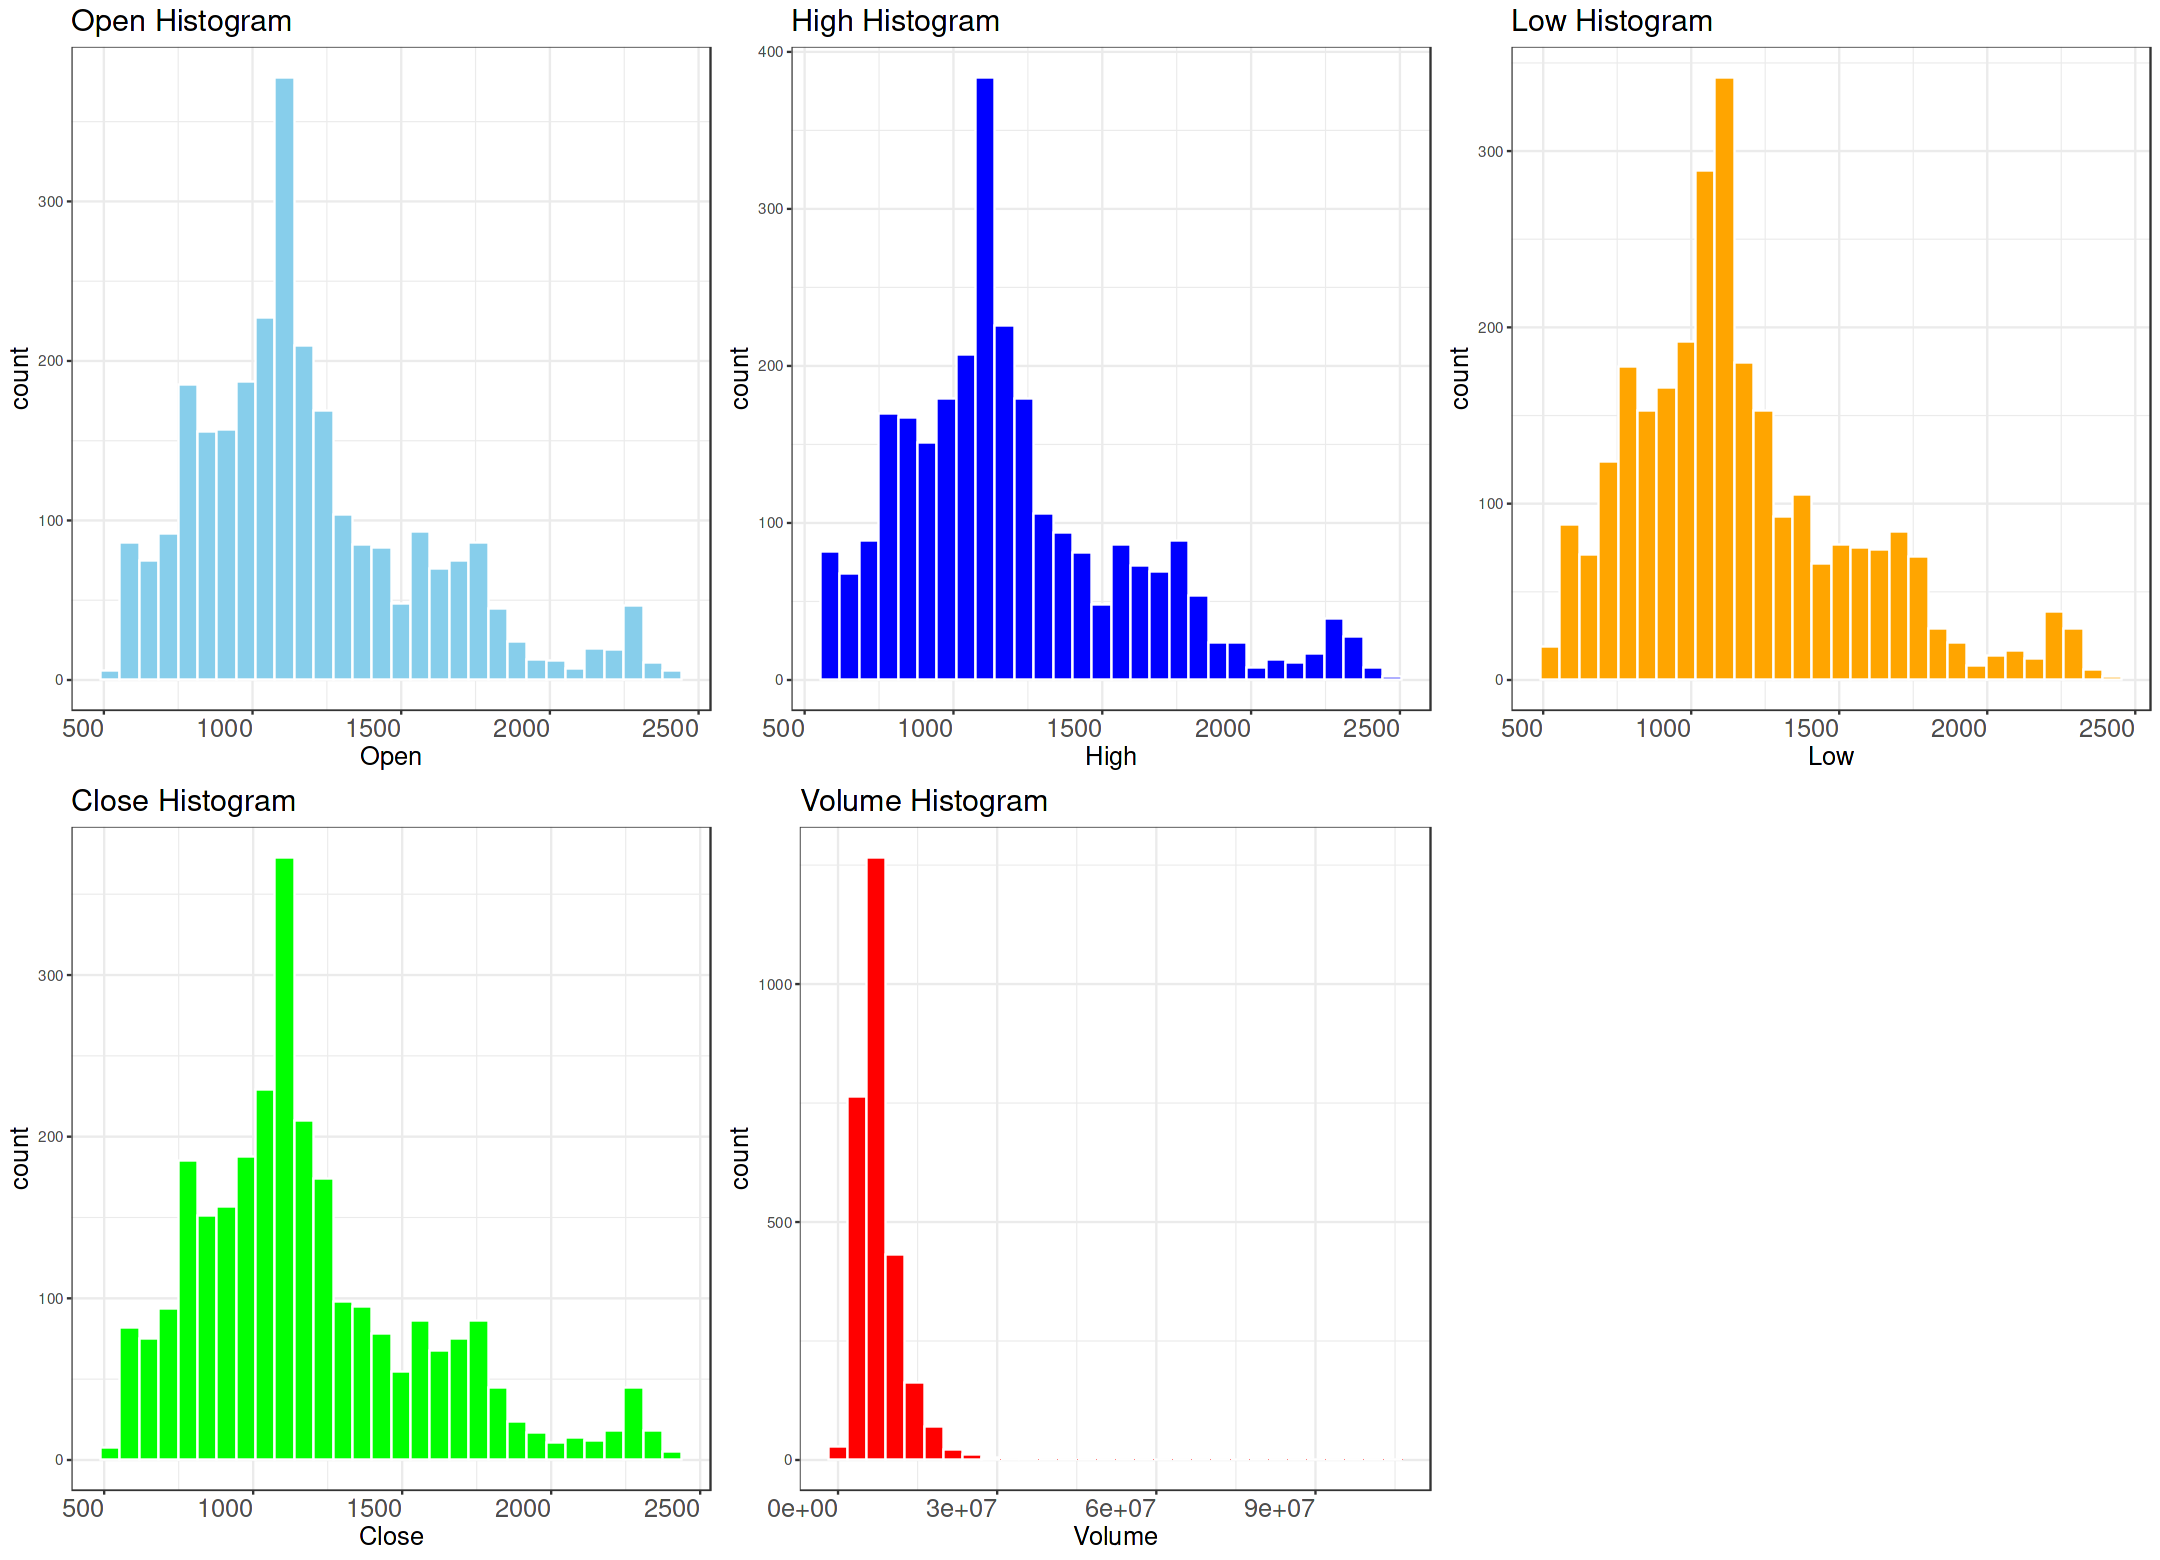

In [250]:
grid.arrange(p1,p2,p3,p4,p5, ncol = 3)

### **Lineplot**

In [251]:
p1 <- ggplot(df, aes(x=Date, y= Open)) + geom_line(color = 'skyblue' ) + ggtitle('Change in \'Open\' by year') +    
    theme_bw() +
    theme(axis.title = element_text(size=15),
    axis.text.x = element_text(size = 15, hjust=1),
    title = element_text(size=15)
    )

p2 <- ggplot(df, aes(x=Date, y= High)) + geom_line(color = 'blue') + ggtitle('Change in \'High\' by year') + 
    theme_bw() +
    theme(axis.title = element_text(size=15),
    axis.text.x = element_text(size = 15, hjust=1),
    title = element_text(size=15)
    )

p3 <- ggplot(df, aes(x=Date, y= Low)) + geom_line(color = 'orange') + ggtitle('Change in \'Low\' by year') + 
    theme_bw() +
    theme(axis.title = element_text(size=15),
    axis.text.x = element_text(size = 15, hjust=1),
    title = element_text(size=15)
    )

p4 <- ggplot(df, aes(x=Date, y= Close)) + geom_line(color = 'green') + ggtitle('Change in \'Close\' by year') + 
    theme_bw() +    
    theme(axis.title = element_text(size=15),
    axis.text.x = element_text(size = 15, hjust=1),
    title = element_text(size=15)
    )

p5 <- ggplot(df, aes(x=Date, y= Volume)) + geom_line(color = 'red') + ggtitle('Change in \'Volume\' by year') + 
    theme_bw() + 
    theme(axis.title = element_text(size=15),
    axis.text.x = element_text(size = 15, hjust=1),
    title = element_text(size=15)
    )

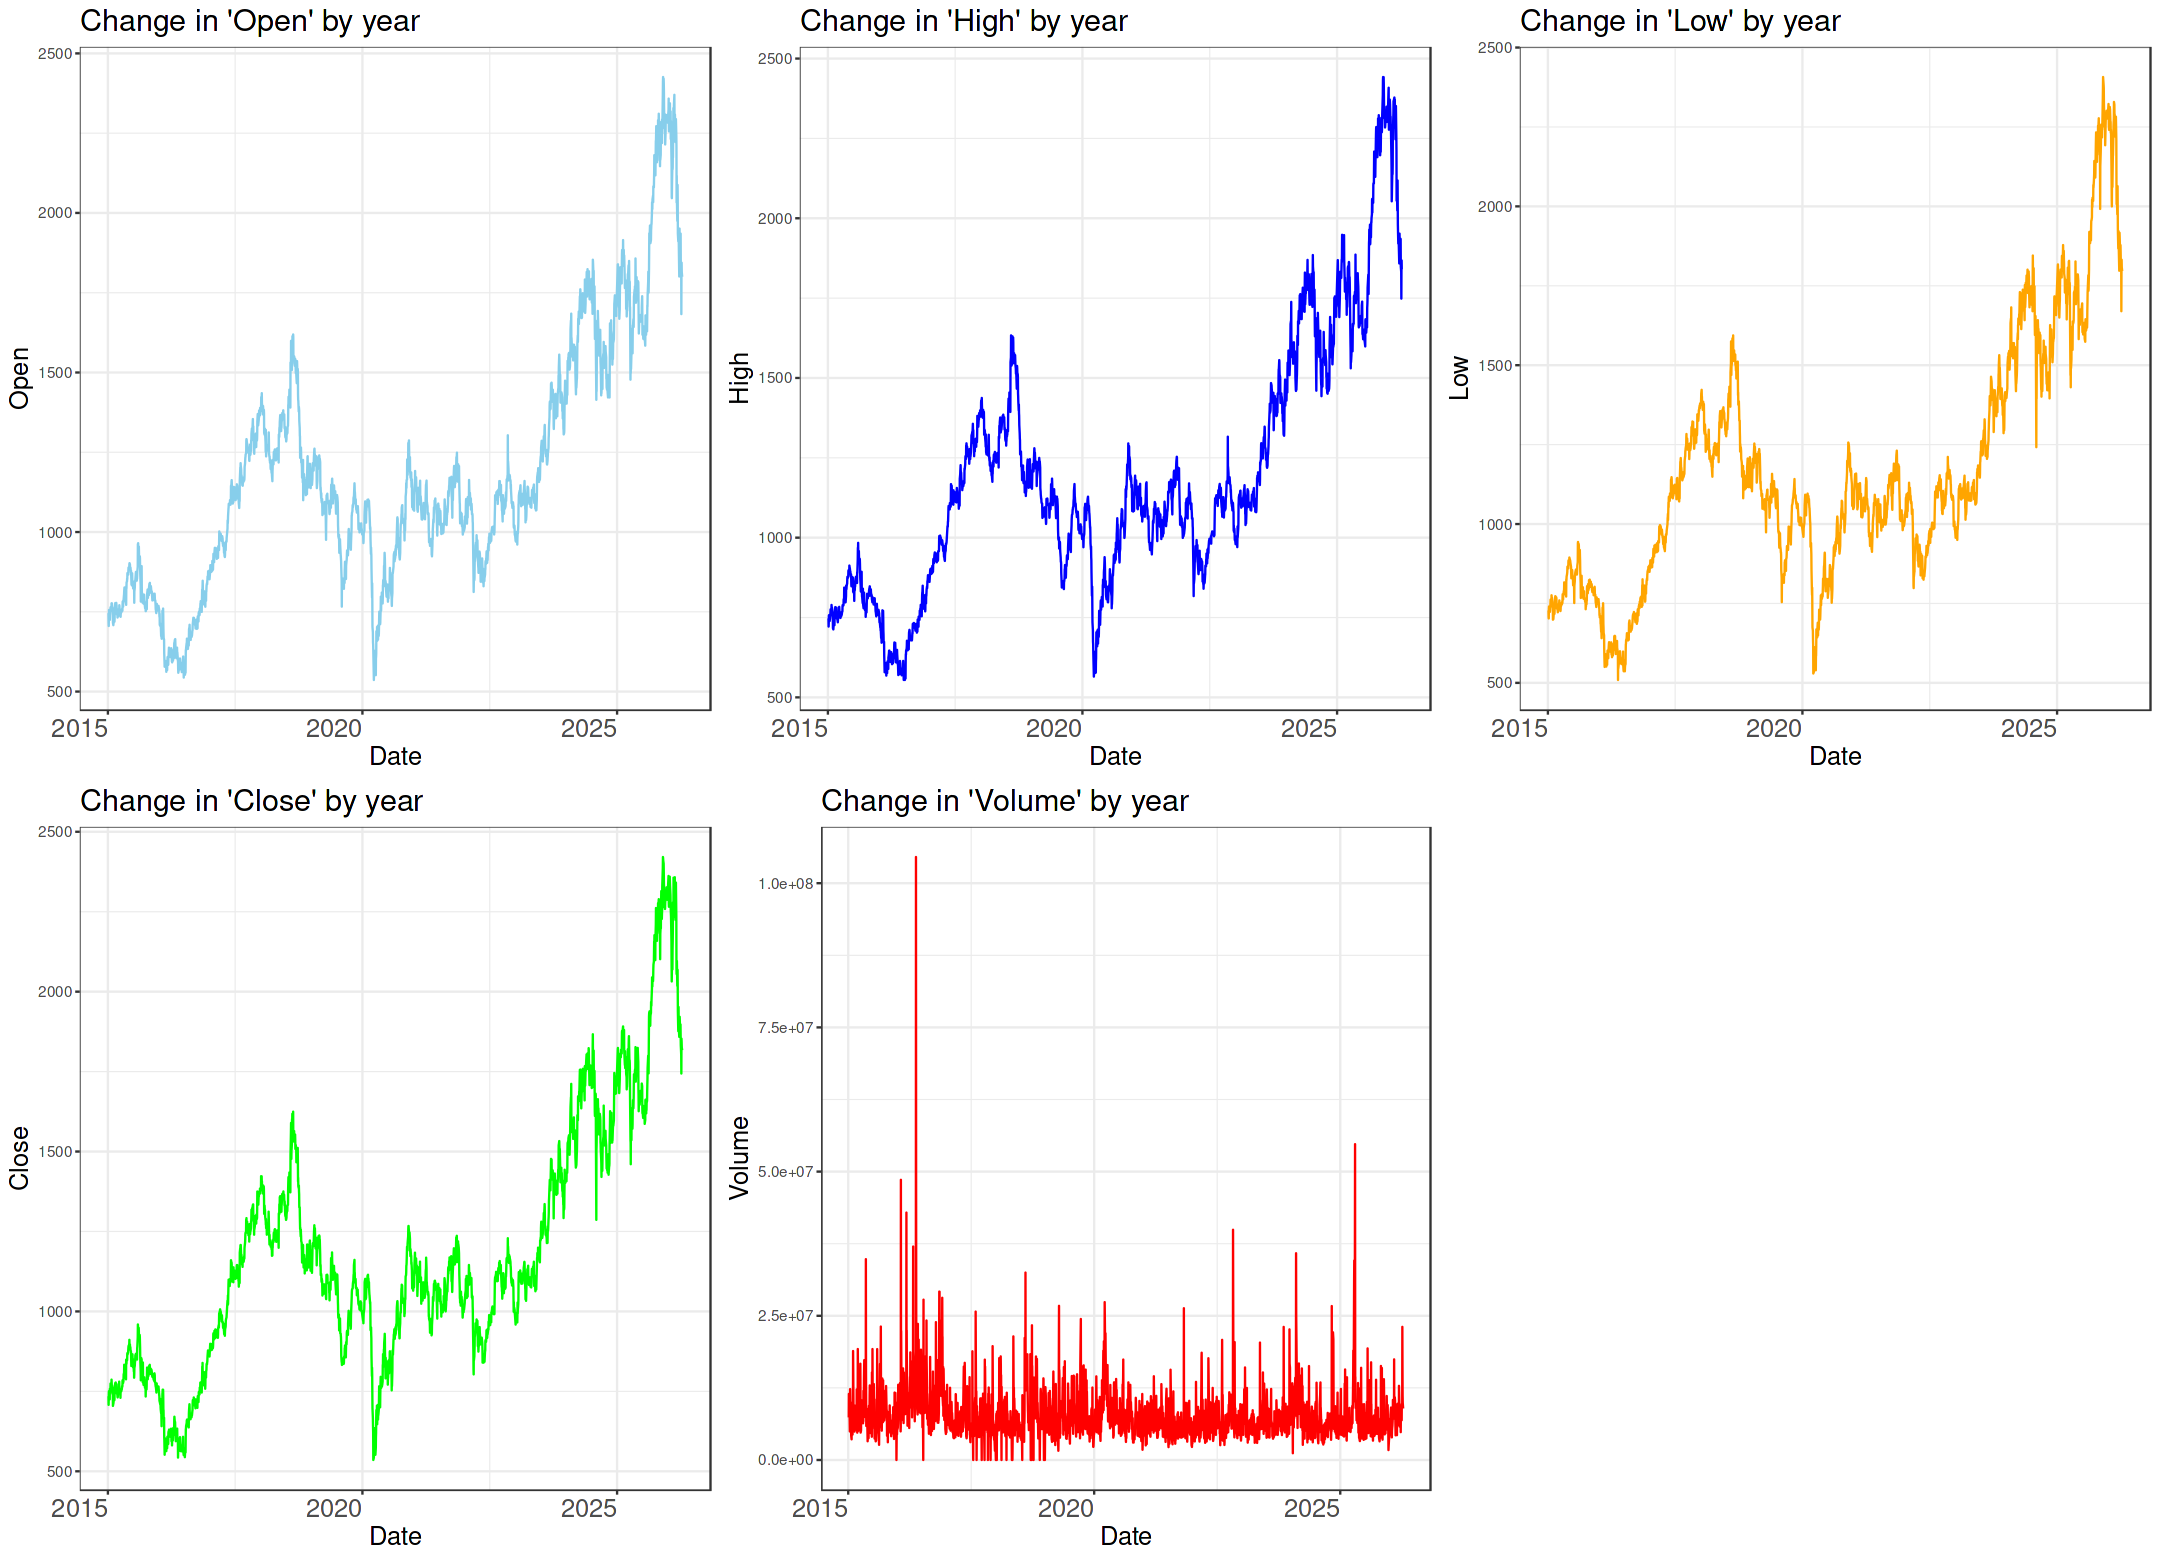

In [252]:
grid.arrange(p1,p2,p3,p4,p5, ncol = 3)

### **Rolling windows(5 Days, 20Days, 60Days) of Close**

In [253]:
temp <- zoo::zoo(df$Close, df$Date)
temp_rollmean5 <- zoo::rollmean(temp, 5 , fill = list(NA, NULL, NA))
temp_rollmean20 <- zoo::rollmean(temp, 20 , fill = list(NA, NULL, NA))
temp_rollmean60 <- zoo::rollmean(temp, 60 , fill = list(NA, NULL, NA))

df$mean5_close <- zoo::coredata(temp_rollmean5)
df$mean20_close <- zoo::coredata(temp_rollmean20)
df$mean60_close <- zoo::coredata(temp_rollmean60)

In [254]:
options(repr.plot.width = 20.0, repr.plot.height = 10.0)

Warning message:
“Removed 4 rows containing missing values or values outside the scale range
(`geom_line()`).”
Warning message:
“Removed 19 rows containing missing values or values outside the scale range
(`geom_line()`).”
Warning message:
“Removed 59 rows containing missing values or values outside the scale range
(`geom_line()`).”


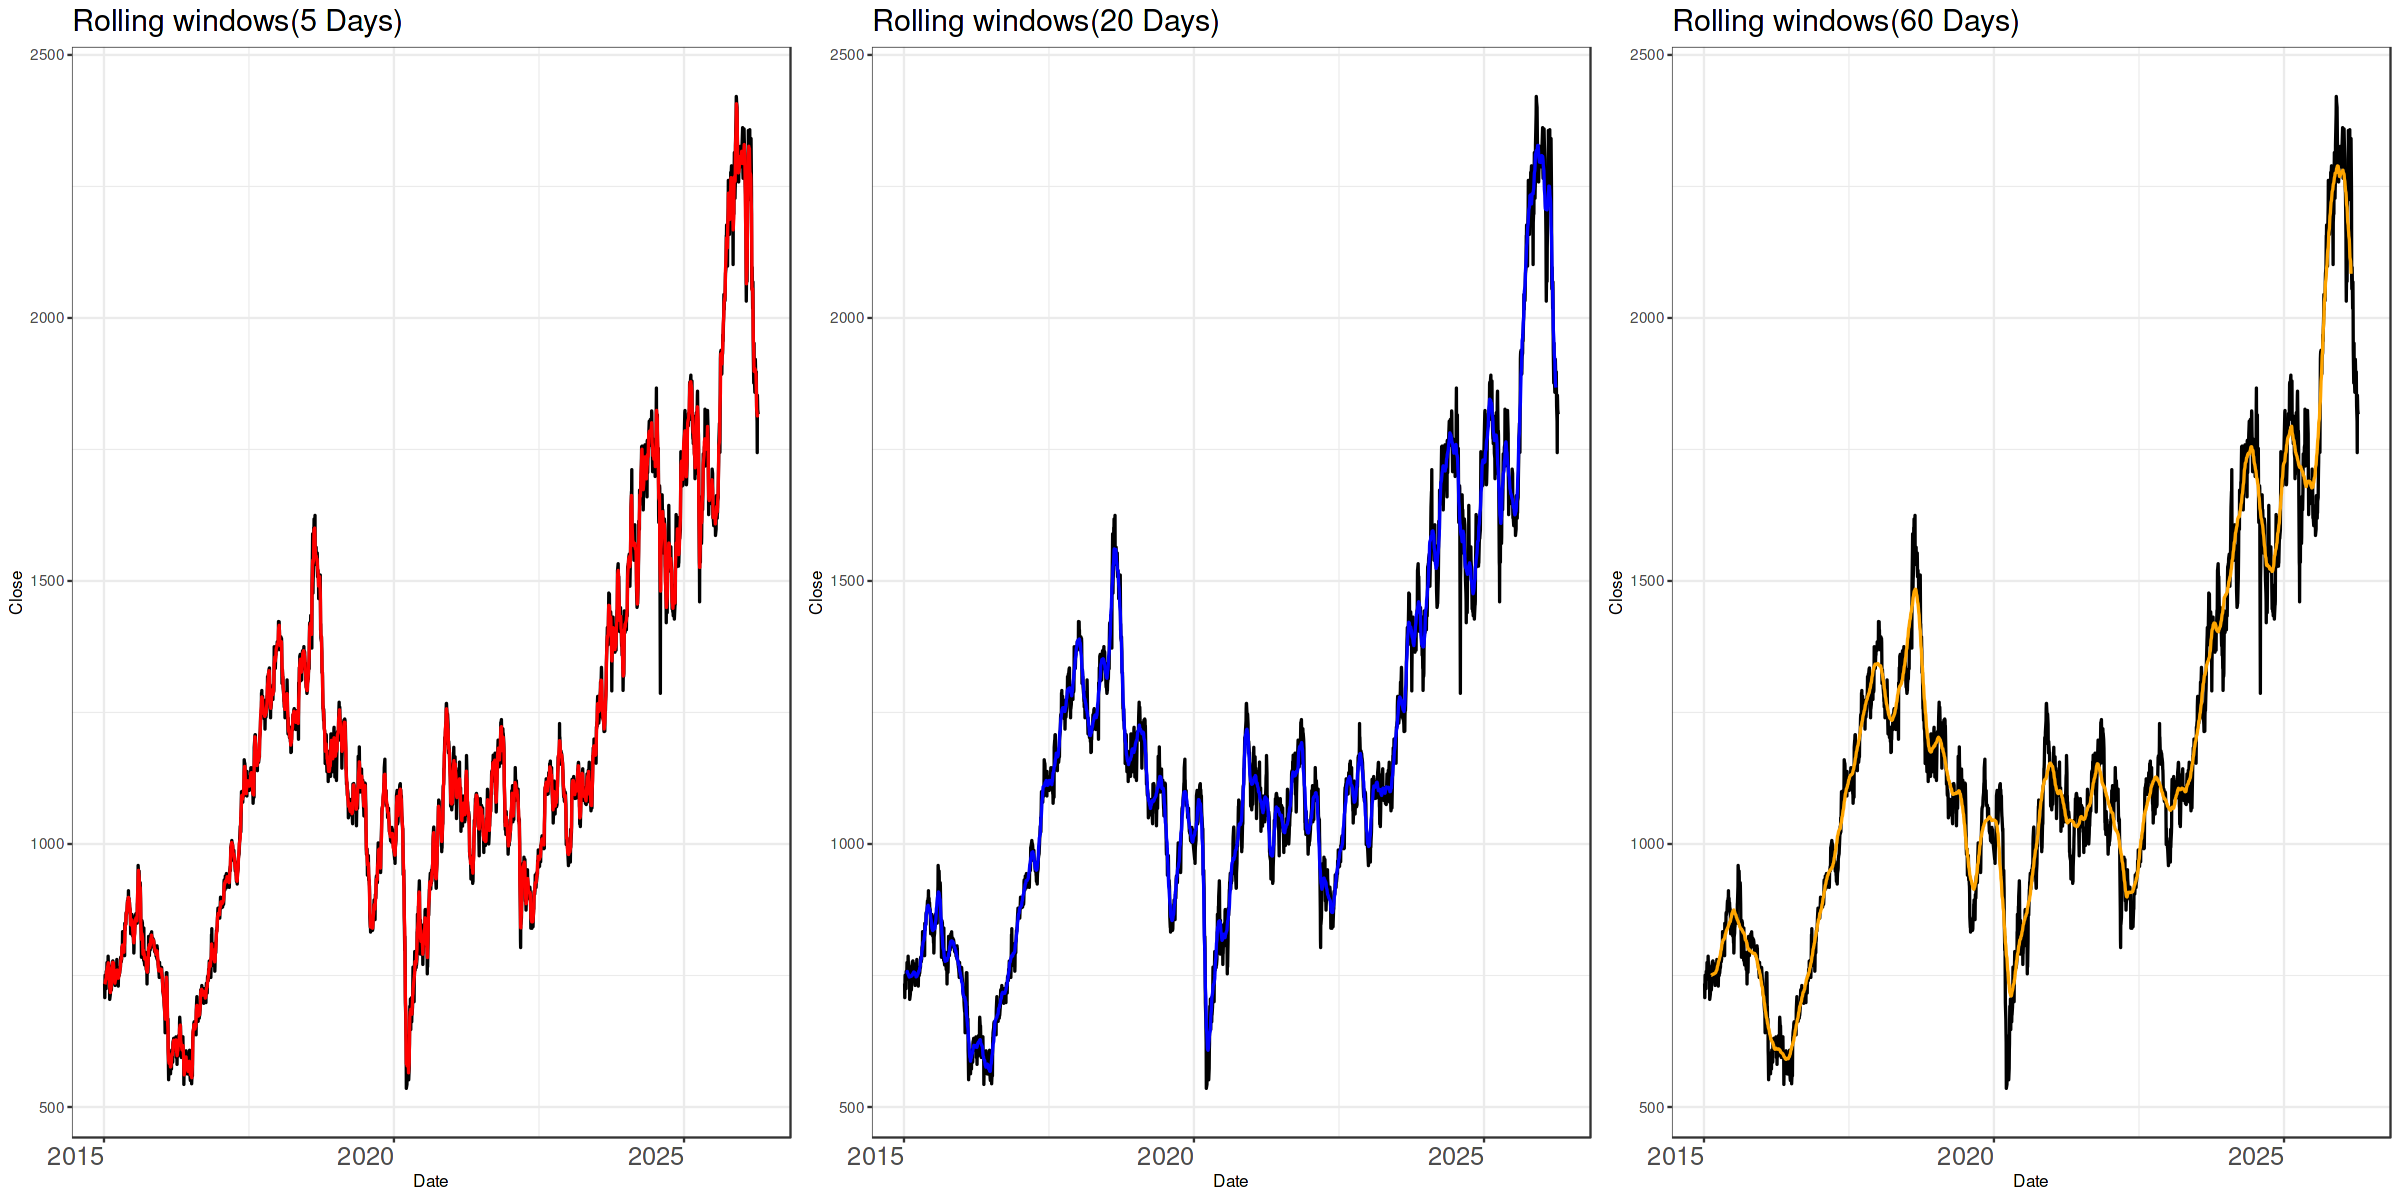

In [255]:
p1 <- ggplot(df, aes(x = Date, y = Close)) + 
        geom_line(color = 'black', size = 0.7) +
        geom_line(aes(Date, mean5_close), color = 'red', size = 0.7) +
        ggtitle('Rolling windows(5 Days)') +
        theme_bw() +
        theme(axis.title = element_text(size=10),
        axis.text.x = element_text(size = 15, hjust=1),
        title = element_text(size=15)
        )

p2 <- ggplot(df, aes(x = Date, y = Close)) + 
        geom_line(color = 'black', size = 0.7) +
        geom_line(aes(Date, mean20_close), color = 'blue', size = 0.7) +
        ggtitle('Rolling windows(20 Days)') +
        theme_bw() +
        theme(axis.title = element_text(size=10),
        axis.text.x = element_text(size = 15, hjust=1),
        title = element_text(size=15)
        )

p3 <- ggplot(df, aes(x = Date, y = Close)) + 
        geom_line(color = 'black', size = 0.7) +
        geom_line(aes(Date, mean60_close), color = 'orange', size = 0.7) +
        ggtitle('Rolling windows(60 Days)') +
        theme_bw() +
        theme(axis.title = element_text(size=10),
        axis.text.x = element_text(size = 15, hjust=1),
        title = element_text(size=15)
        )

grid.arrange(p1,p2,p3, ncol = 3)

### **Create Derivative Variables**

In [256]:
df <- df %>%
  arrange(Date) %>%
  mutate(
    dist_ma20_pct = (Close - mean20_close) / mean20_close,
    ma20_slope = mean20_close - lag(mean20_close),
    return = Close / lag(Close) - 1,
    abs_return = abs(return)
  ) %>%
  na.omit()

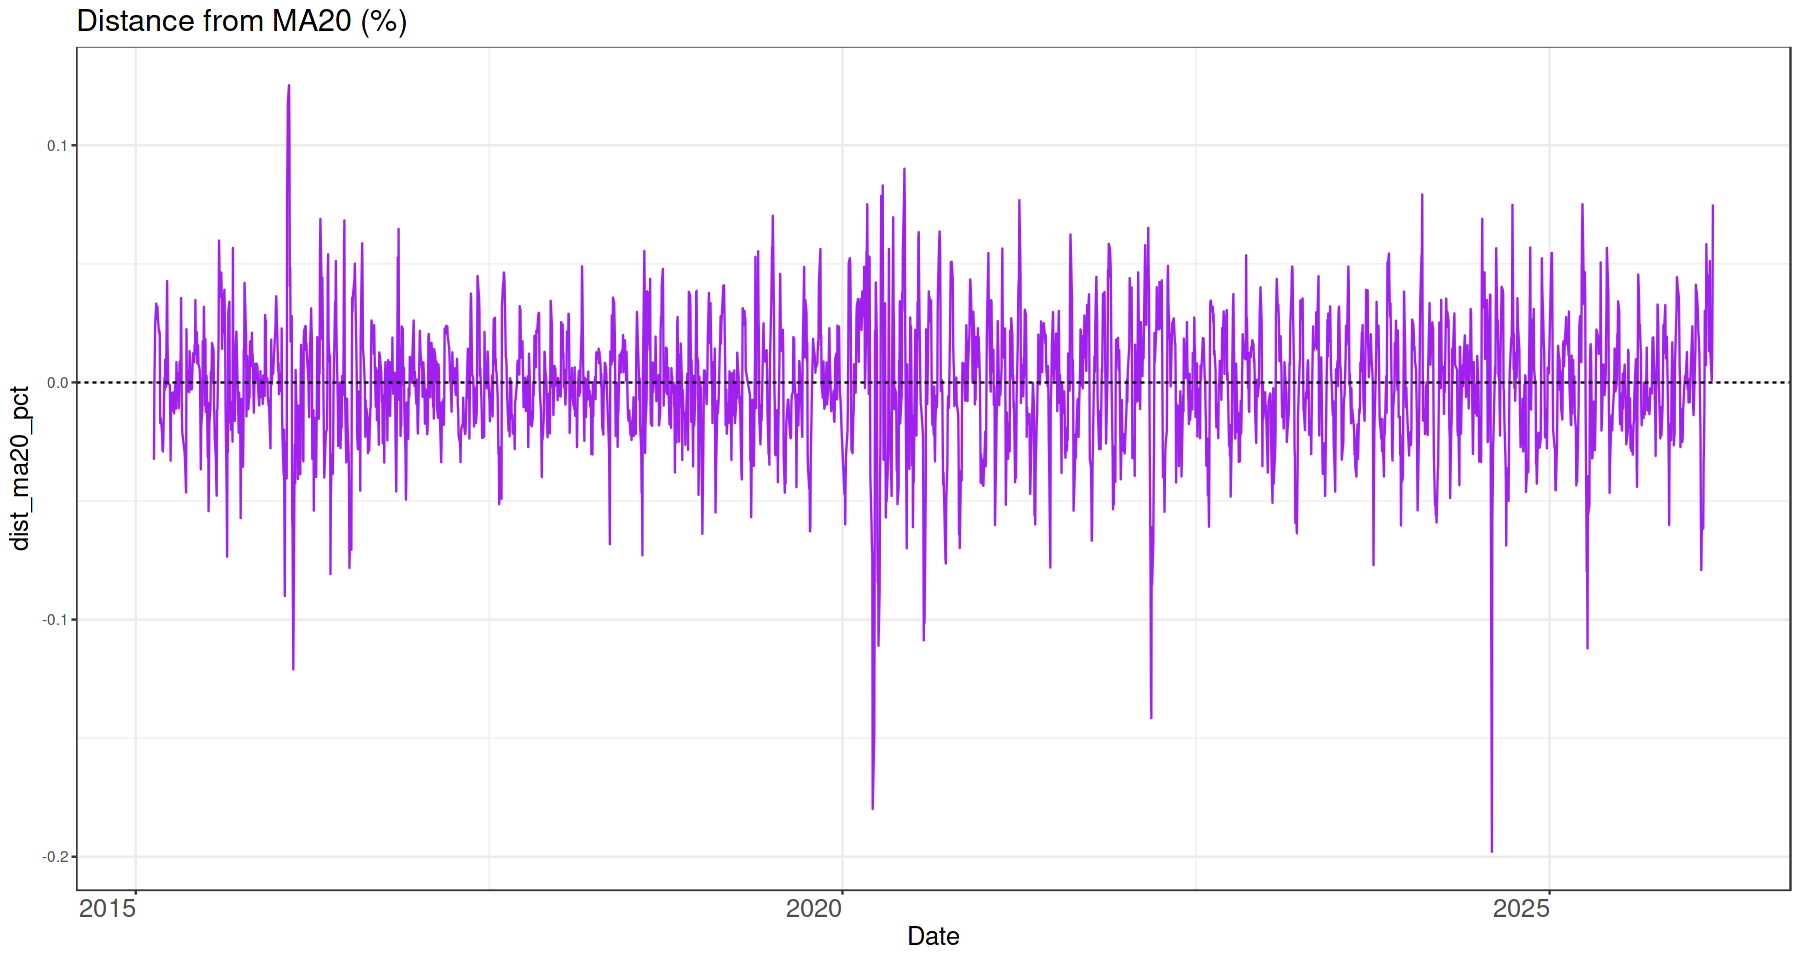

In [257]:
options(repr.plot.width = 15.0, repr.plot.height = 8.0)

ggplot(df, aes(x = Date, y = dist_ma20_pct)) +
  geom_line(color = "purple") +
  geom_hline(yintercept = 0, linetype = "dashed") +
  labs(title = "Distance from MA20 (%)") +
    theme_bw() +
        theme(axis.title = element_text(size=10),
        axis.text.x = element_text(size = 15, hjust=1),
        title = element_text(size=15),
        axis.title.x = element_text(size = 15),
        axis.title.y = element_text(size = 15)
              )

👉 **Observation**   
* Most of them vibrate near zero.   
* Sometimes there is a sharp drop between -0.15 and -0.2   
* The bottom tail is bigger than the direction
  
👉 **Interpretation**  
* Market close to average in general → normal   
* But if it falls, it's very different from the average   
* The risk comes not from the rise, but from the fall   

### **Distribution of Distance from MA20**

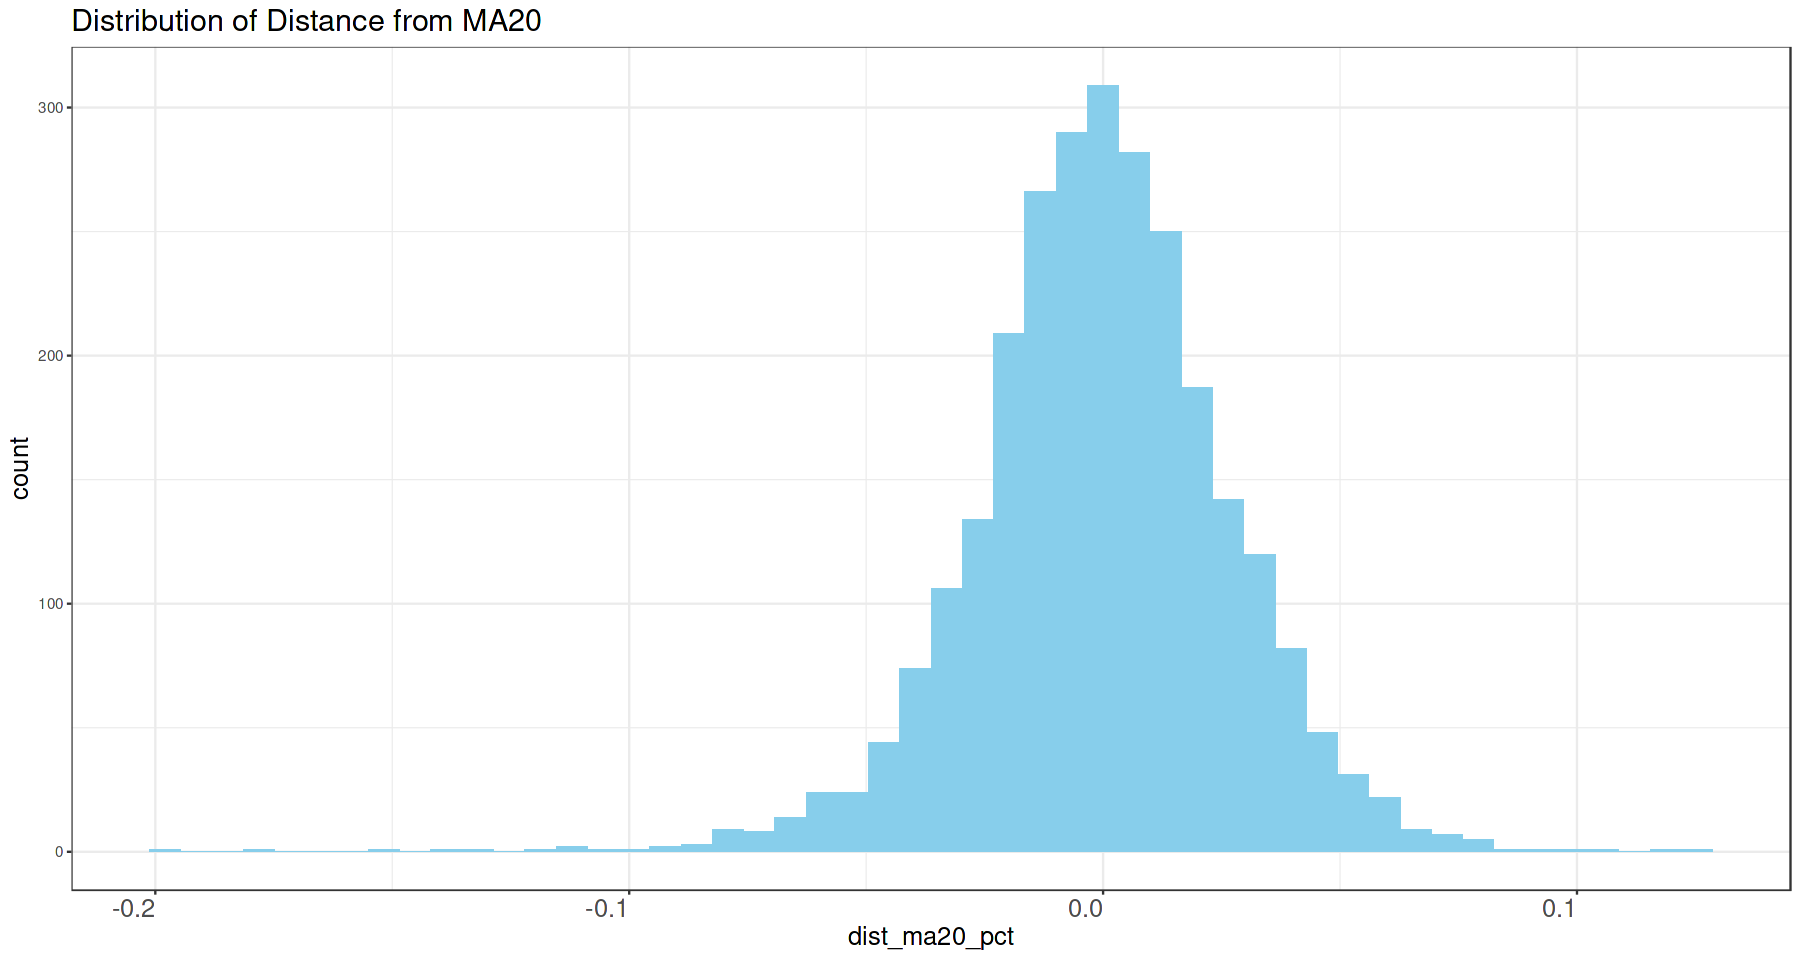

In [258]:
ggplot(df, aes(x = dist_ma20_pct)) +
  geom_histogram(bins = 50, fill = "skyblue") +
  labs(title = "Distribution of Distance from MA20") +
       theme_bw() +
        theme(
        axis.title = element_text(size=10),
        axis.text.x = element_text(size = 15, hjust=1),
        title = element_text(size=15),
        axis.title.x = element_text(size = 15),
        axis.title.y = element_text(size = 15)
              )

👉 **Observation**   
* Centralized (near zero)
* Both tails (fat-tail)
* Especially the left tail is thicker
  
👉 **Interpretation**  
* Not normally distributed → tail risk exists
* 'The average movement' is small.   
* Sometimes it's a big shock → Typical Features of Financial Data

### **Distance vs Volatility**

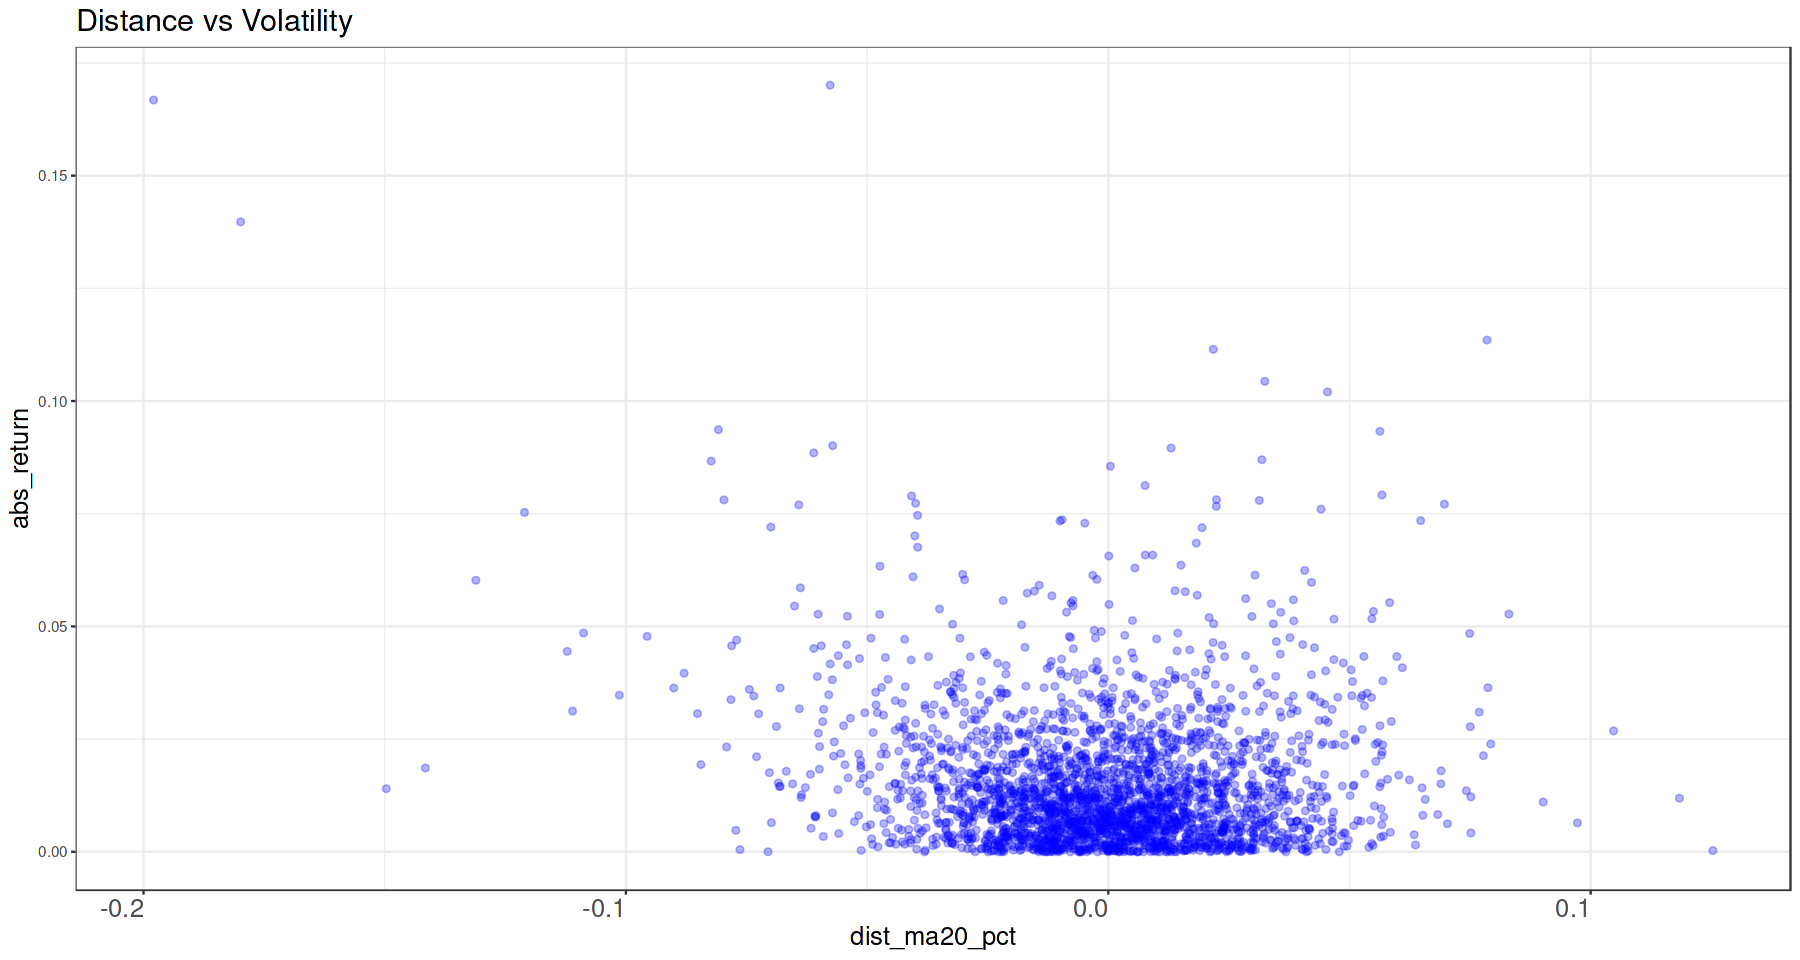

In [259]:
ggplot(df, aes(x = dist_ma20_pct, y = abs_return)) +
  geom_point(alpha = 0.3, color = "blue") +
  labs(title = "Distance vs Volatility") +
       theme_bw() +
        theme(
        axis.title = element_text(size=10),
        axis.text.x = element_text(size = 15, hjust=1),
        title = element_text(size=15),
        axis.title.x = element_text(size = 15),
        axis.title.y = element_text(size = 15)
              )

👉 **Observation**

* Small variability at center (near zero)
* Abs_return increases with distance
* Diffusion structure, though not perfectly linear
  
👉 **Interpretation**

Risk increases as you move away from the mean.      
* Near MA → Stable
* Departure from MA → Hazard

### **MA20 Slope**

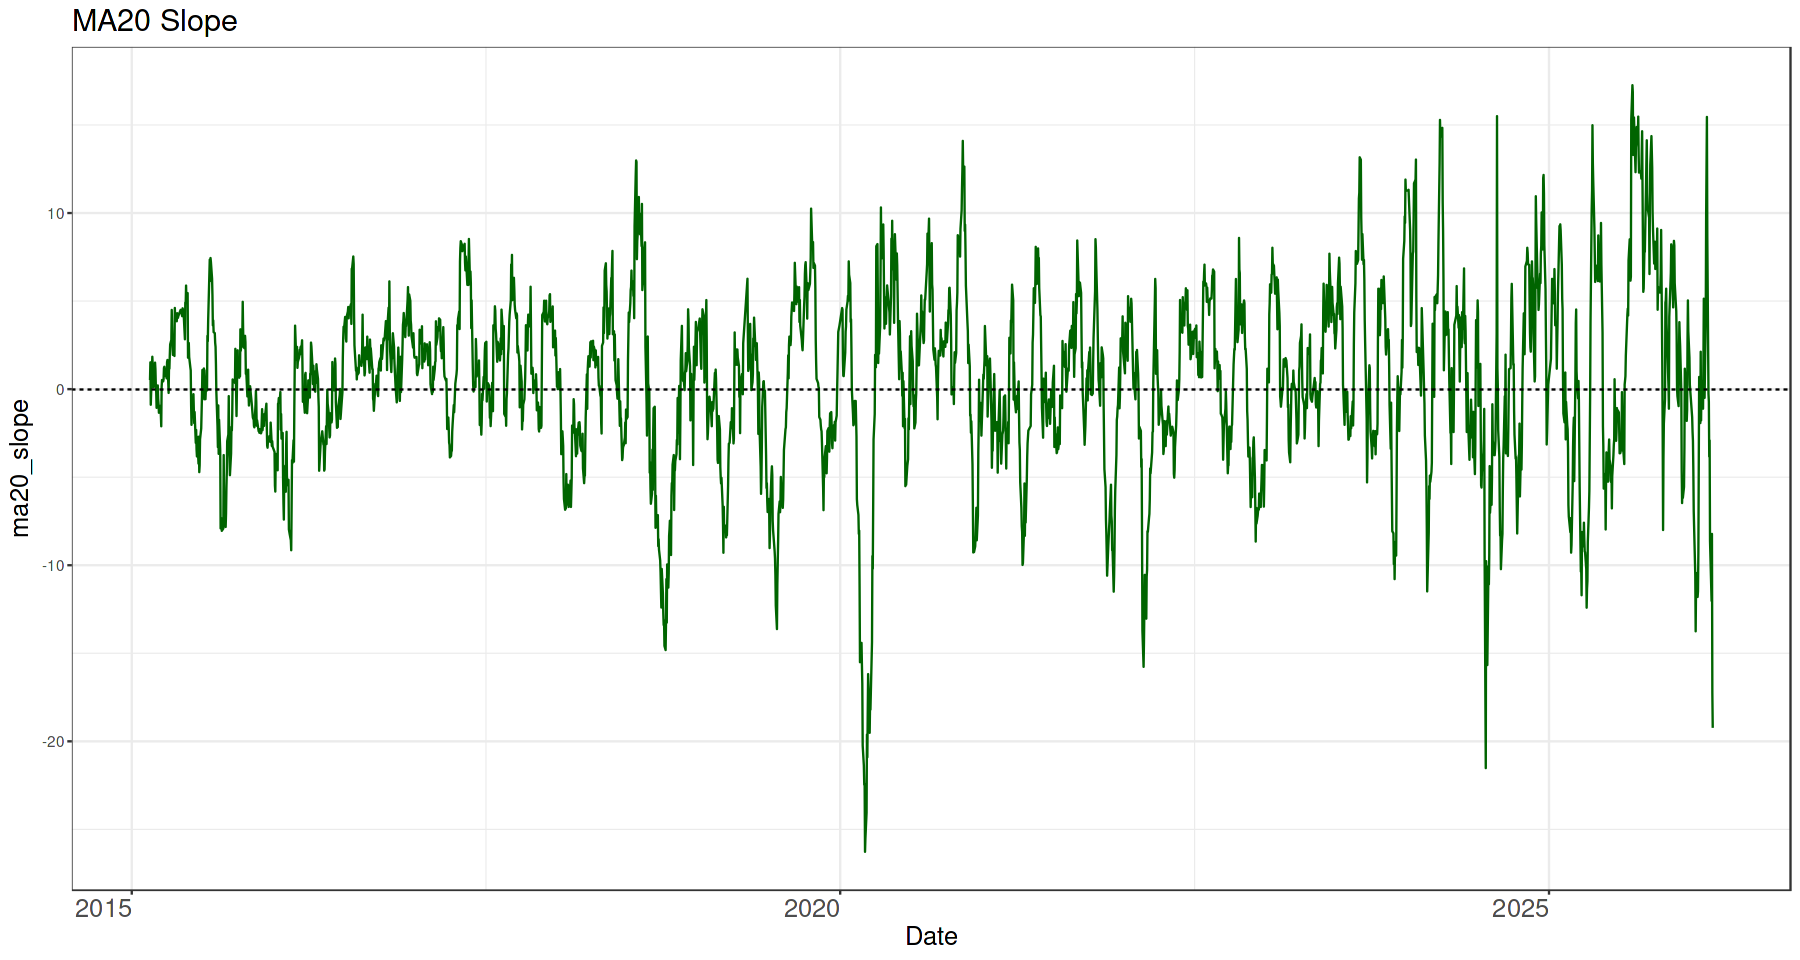

In [260]:
ggplot(df, aes(x = Date, y = ma20_slope)) +
  geom_line(color = "darkgreen") +
  geom_hline(yintercept = 0, linetype = "dashed") +
  labs(title = "MA20 Slope") +
       theme_bw() +
        theme(
        axis.title = element_text(size=10),
        axis.text.x = element_text(size = 15, hjust=1),
        title = element_text(size=15),
        axis.title.x = element_text(size = 15),
        axis.title.y = element_text(size = 15)
              )

👉 **Observation**   
* Vibrate around zero
* a large negative/positive number in a particular interval

👉 **interpretation**

Trends don't stay and change frequently

* slope > 0 → rising trend
* slope < 0 → downward trend

Especially: Large negative interval → When to plunge

### **Return Distribution**

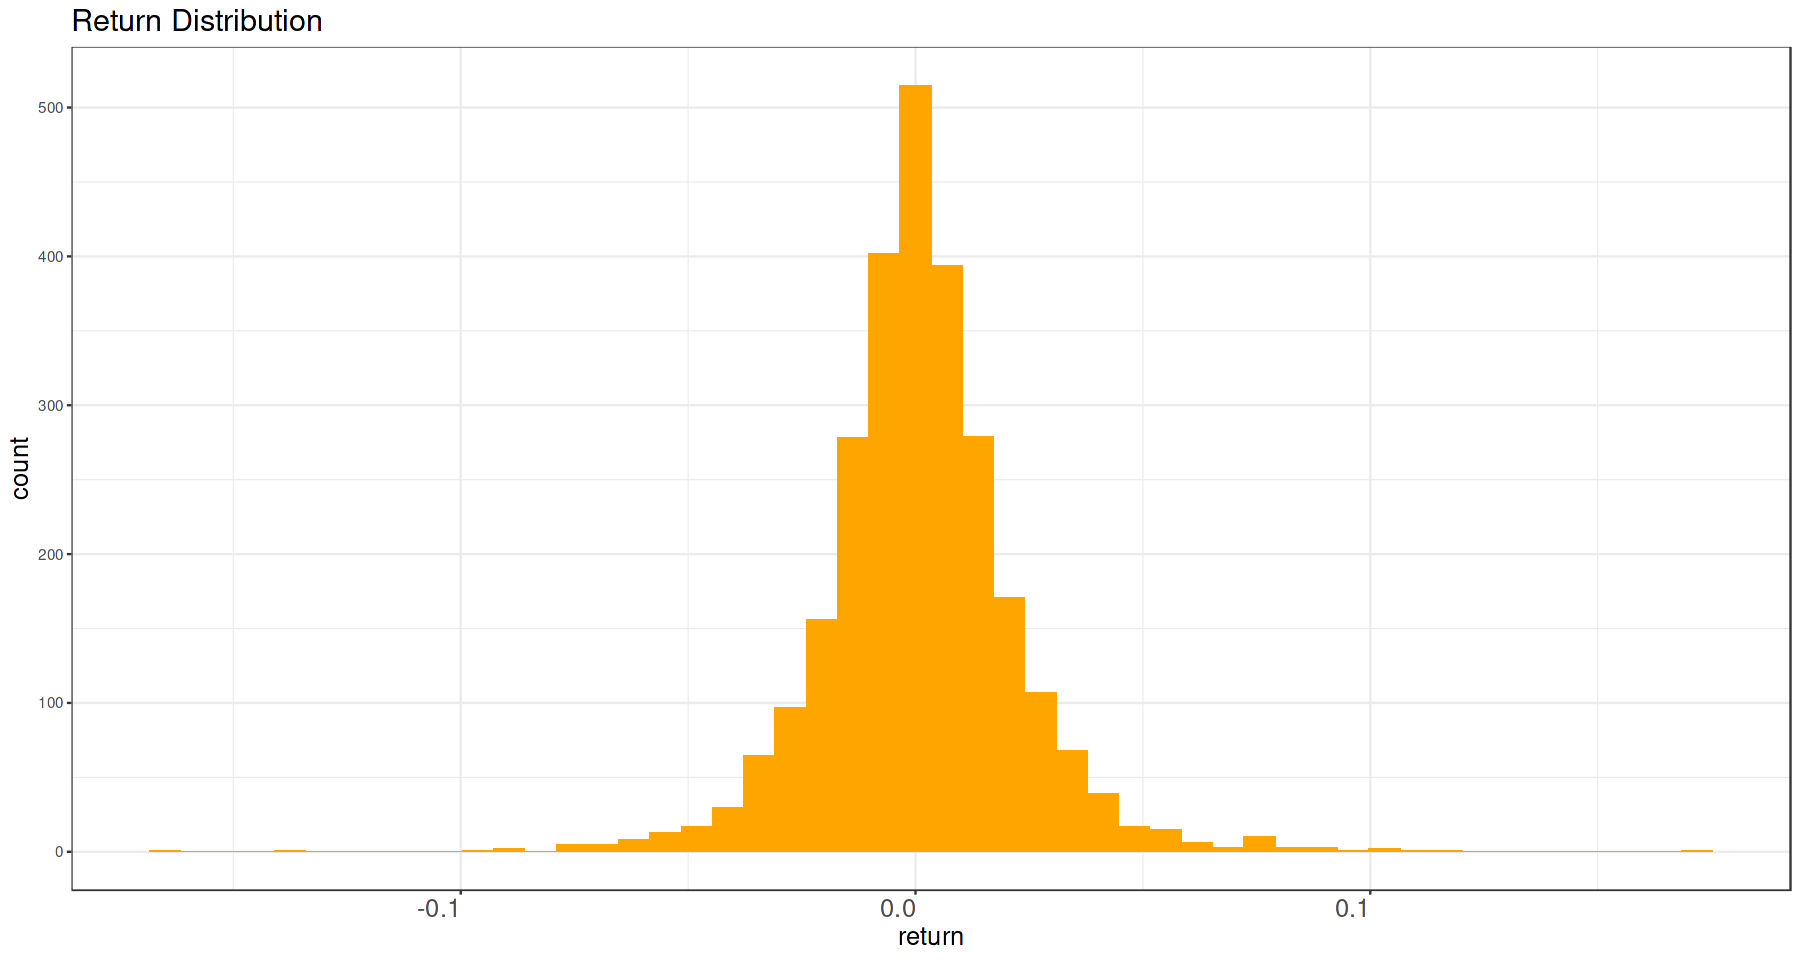

In [261]:
ggplot(df, aes(x = return)) +
  geom_histogram(bins = 50, fill = "orange") +
  labs(title = "Return Distribution") +
       theme_bw() +
        theme(
        axis.title = element_text(size=10),
        axis.text.x = element_text(size = 15, hjust=1),
        title = element_text(size=15),
        axis.title.x = element_text(size = 15),
        axis.title.y = element_text(size = 15)
              )

**Yields are not normally distributed → Risk exists**

### **Rolling Volatility (20)**

Warning message:
“Removed 19 rows containing missing values or values outside the scale range
(`geom_line()`).”


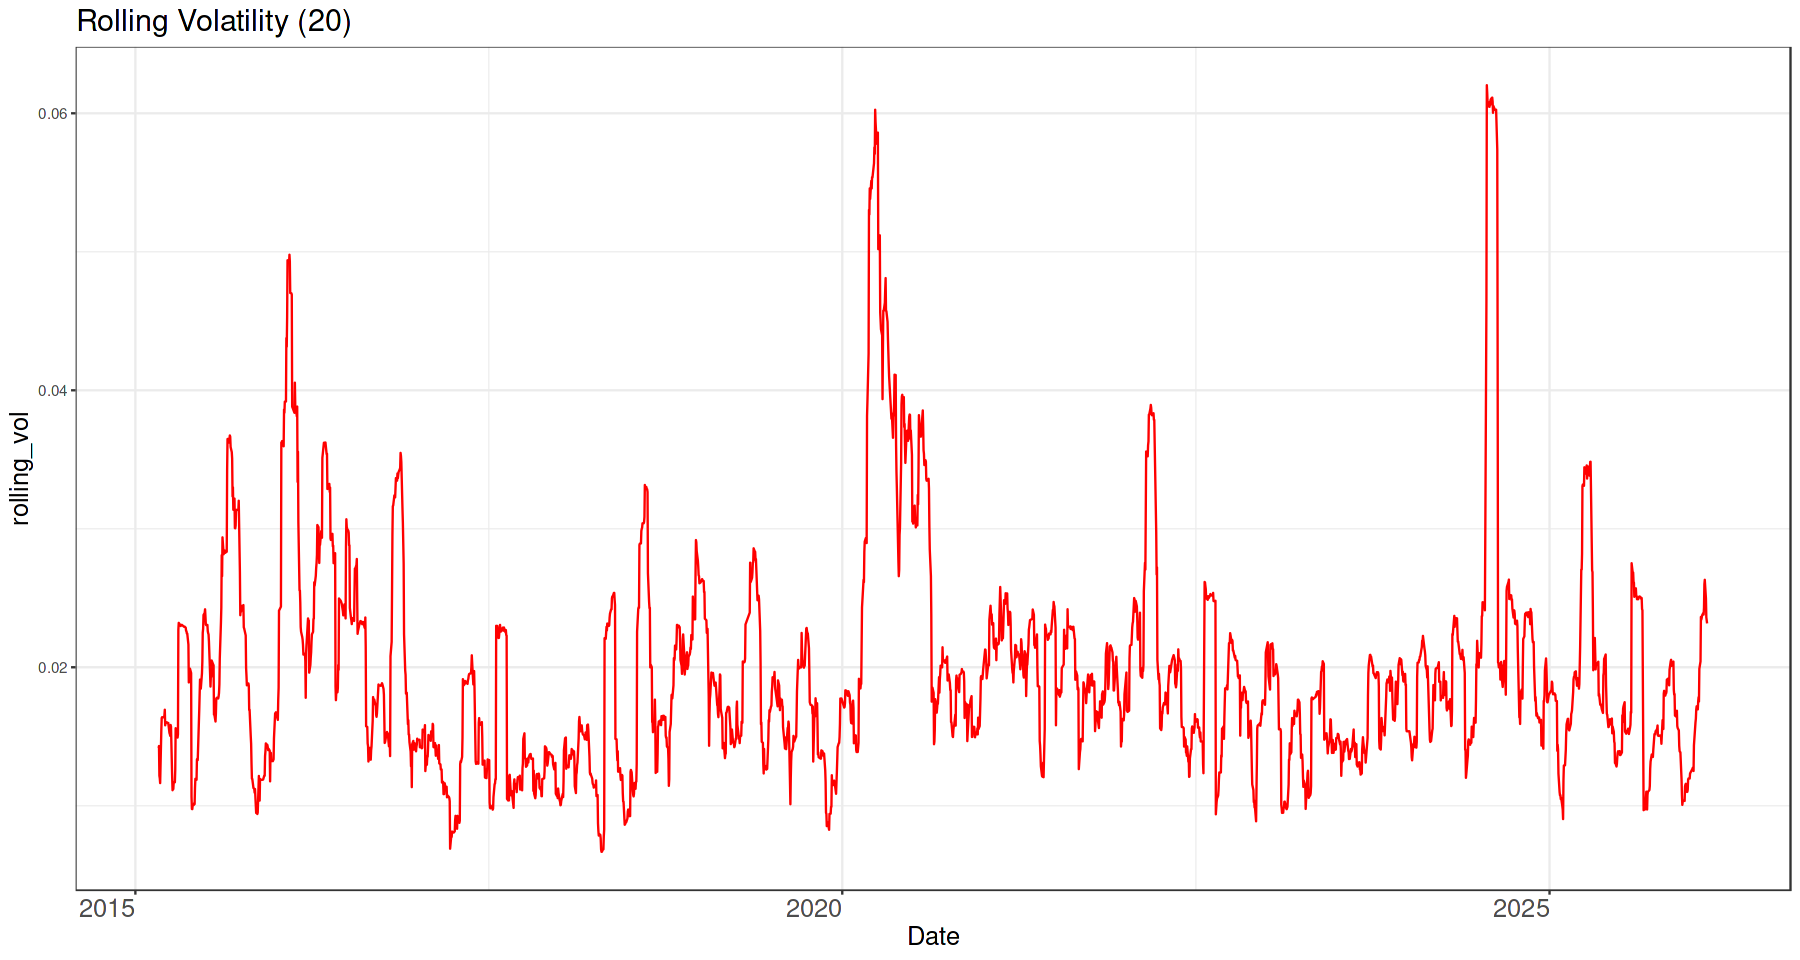

In [262]:
df$rolling_vol <- zoo::rollapply(df$return, 20, sd, fill = NA)

ggplot(df, aes(x = Date, y = rolling_vol)) +
  geom_line(color = "red") +
  labs(title = "Rolling Volatility (20)") +
       theme_bw() +
        theme(
        axis.title = element_text(size=10),
        axis.text.x = element_text(size = 15, hjust=1),
        title = element_text(size=15),
        axis.title.x = element_text(size = 15),
        axis.title.y = element_text(size = 15)
              )

👉 **Observation**
* Unconstant
* Surging at a certain point
* "Like a lump"

👉 **Interpretation:**

Volatility clustering present   
The risk is not random "There's a dangerous time."

### **Drawdown**

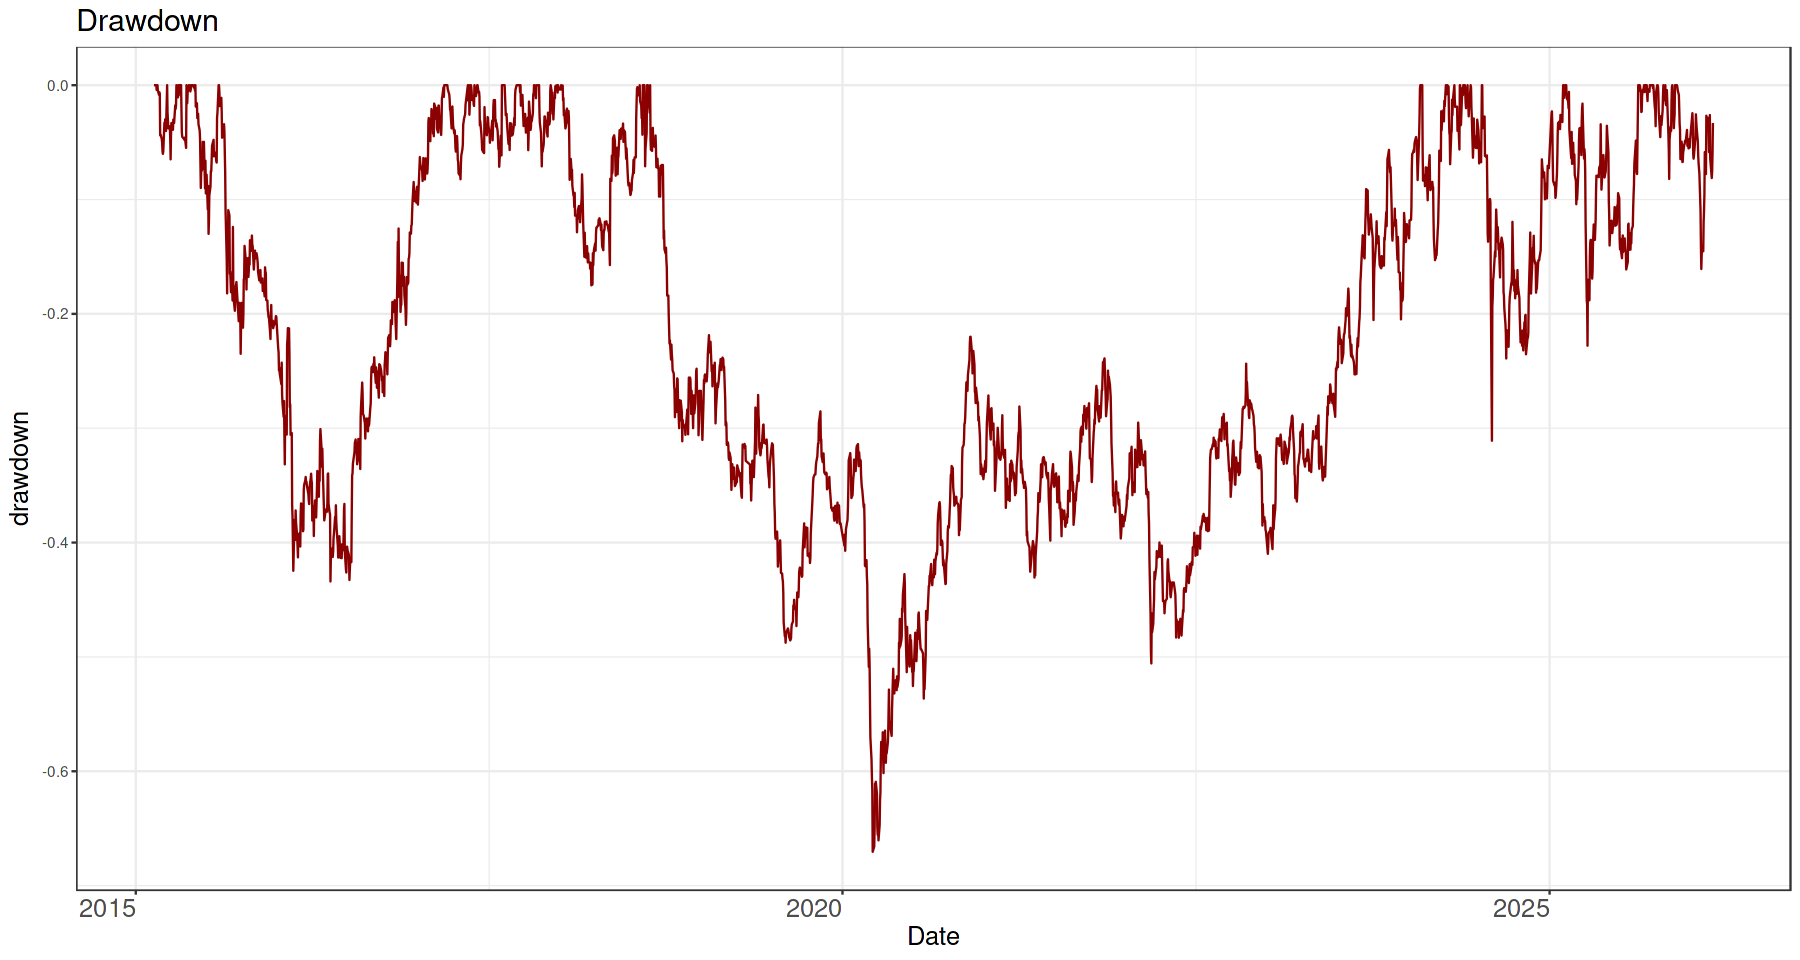

In [263]:
df <- df %>%
  mutate(
    cum_max = cummax(Close),
    drawdown = (Close - cum_max) / cum_max
  )

ggplot(df, aes(x = Date, y = drawdown)) +
  geom_line(color = "darkred") +
  labs(title = "Drawdown") +
       theme_bw() +
        theme(
        axis.title = element_text(size=10),
        axis.text.x = element_text(size = 15, hjust=1),
        title = element_text(size=15),
        axis.title.x = element_text(size = 15),
        axis.title.y = element_text(size = 15)
              )

👉 **Observation**

* -Falling to the 60% level.   
* Concentrate large falls in a specific period of time.
  
👉 **Interpretation:**

The actual risk is very high 

### **Extreme Distance (Top 5%)**

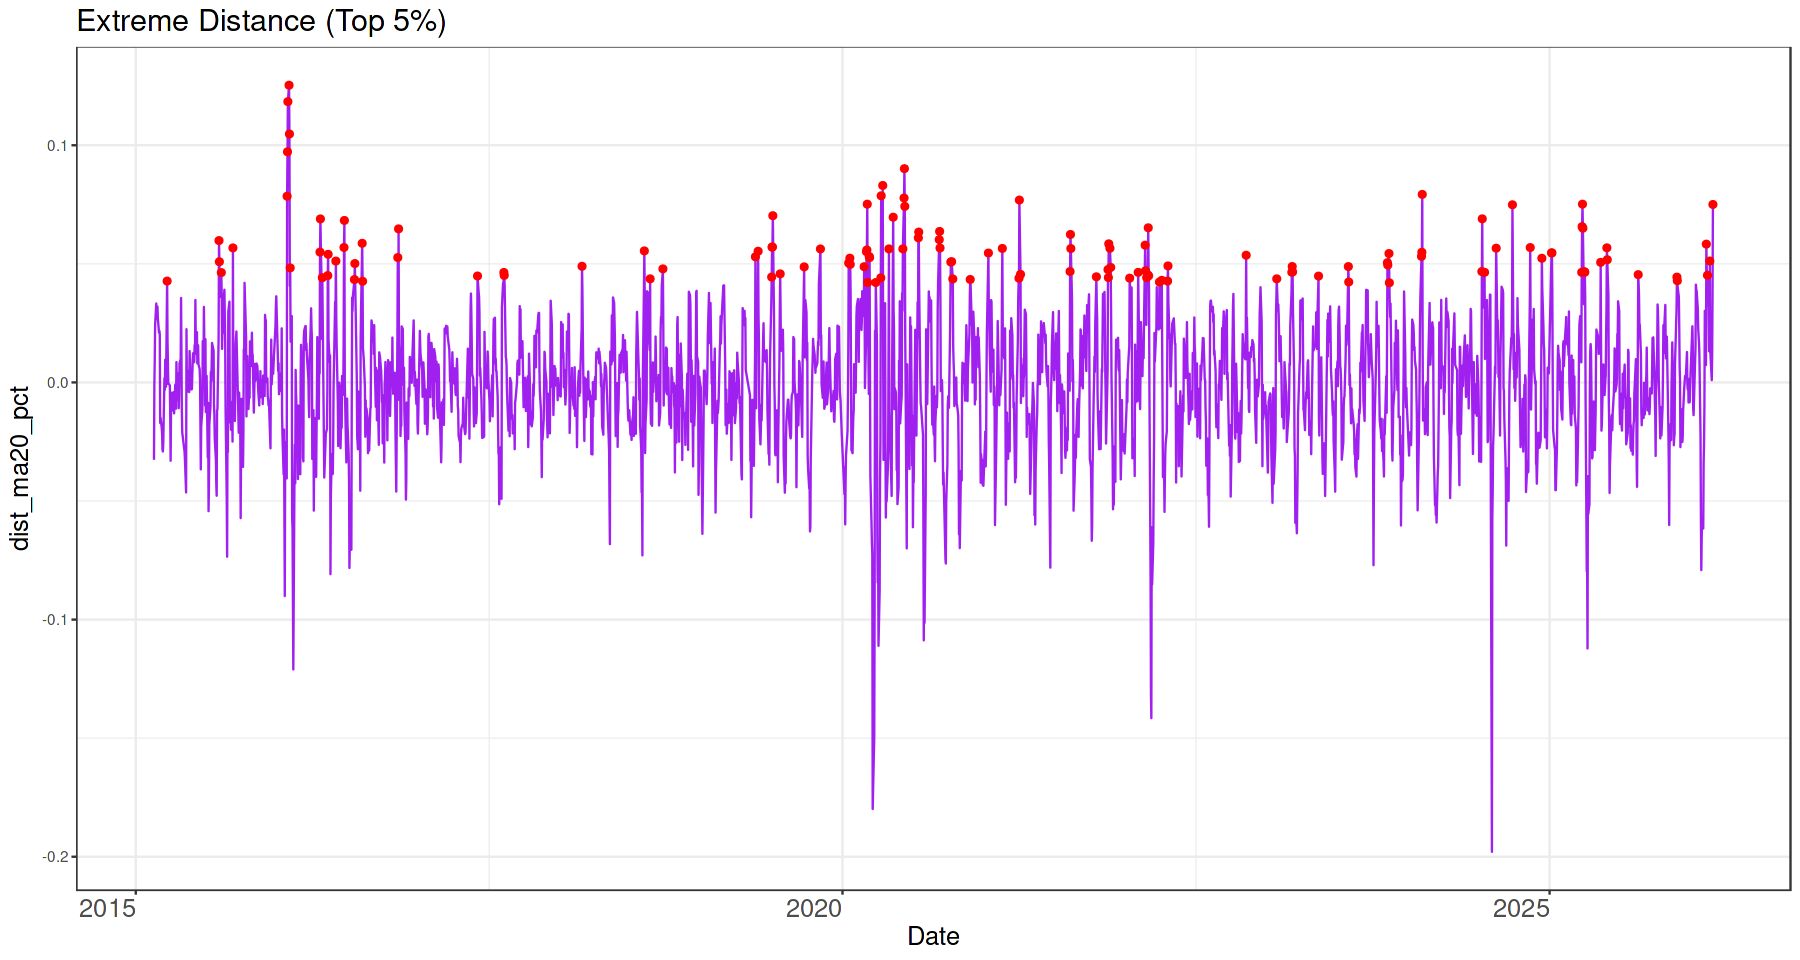

In [264]:
threshold <- quantile(df$dist_ma20_pct, 0.95)

ggplot(df, aes(x = Date, y = dist_ma20_pct)) +
  geom_line(color = "purple") +
  geom_point(
    data = df[df$dist_ma20_pct > threshold, ],
    aes(x = Date, y = dist_ma20_pct),
    color = "red"
  ) +
  labs(title = "Extreme Distance (Top 5%)") +
       theme_bw() +
        theme(
        axis.title = element_text(size=10),
        axis.text.x = element_text(size = 15, hjust=1),
        title = element_text(size=15),
        axis.title.x = element_text(size = 15),
        axis.title.y = element_text(size = 15)
              )

Extreme section is crowded at a certain point in time.      
Extreme values are also clustered. Risk events are not independent.   

**This data is normally stable, but it's a structure where danger explodes in certain sections.**

# **ML & Risk Analysis.**

In [265]:
library(keras3)

In [266]:
df_model <- df %>%
  arrange(Date) %>%
  mutate(
    return = Close / dplyr::lag(Close) - 1,
    abs_return = abs(return),
    MA20 = zoo::rollmean(Close, 20, fill = NA, align = "right"),
    dist_ma20_pct = (Close - MA20) / MA20,
    ma20_slope = MA20 - dplyr::lag(MA20),
    rolling_vol = zoo::rollapply(return, 20, sd, fill = NA, align = "right"),
    vol_lag1 = dplyr::lag(rolling_vol)
  ) %>%
  select(Date, return, abs_return, dist_ma20_pct, ma20_slope, vol_lag1, rolling_vol) %>%
  na.omit()

In [267]:
features <- df_model[, c("return", "dist_ma20_pct", "ma20_slope","abs_return",'vol_lag1')]
target <- df_model$rolling_vol

### **Scale**

In [268]:
scale_feature <- function(x) {
  (x - mean(x)) / sd(x)
}

features_scaled <- as.data.frame(lapply(features, scale_feature))
target_scaled <- scale_feature(target)

### **Sequence**

In [269]:
make_sequence <- function(X, y, window_size = 20) {
  x <- vector("list", nrow(X) - window_size)
  t <- numeric(nrow(X) - window_size)
  
  for (i in 1:(nrow(X) - window_size)) {
    x[[i]] <- as.matrix(X[i:(i + window_size - 1), ])
    t[i] <- y[i + window_size]
  }
  
  x_array <- array(unlist(x), dim = c(length(x), window_size, ncol(X)))
  list(x = x_array, y = t)
}

seq_data <- make_sequence(features_scaled, target_scaled, 20)

x <- seq_data$x
y <- seq_data$y



### **Train Test Split**

In [270]:
train_size <- floor(0.8 * dim(x)[1])

x_train <- x[1:train_size,,,drop=FALSE]
y_train <- y[1:train_size]

x_test <- x[(train_size+1):dim(x)[1],,,drop=FALSE]
y_test <- y[(train_size+1):length(y)]

In [271]:
library(reticulate)
np <- import("numpy", convert = FALSE)

x_train_np <- np$array(x_train, dtype = "float32")
y_train_np <- np$array(as.numeric(y_train), dtype = "float32")

x_test_np  <- np$array(x_test, dtype = "float32")
y_test_np  <- np$array(as.numeric(y_test), dtype = "float32")

### **LSTM**

In [285]:
timesteps <- dim(x_train)[2]
n_features <- dim(x_train)[3]

model <- keras_model_sequential()
model$add(layer_input(shape = c(as.integer(timesteps), as.integer(n_features))))
model$add(layer_lstm(units = 64L, return_sequences = TRUE))
model$add(layer_dropout(rate = 0.2))
model$add(layer_lstm(units = 32L))
model$add(layer_dropout(rate = 0.2))
model$add(layer_dense(units = 16L, activation = "relu"))
model$add(layer_dense(units = 1L))

model$compile(
  optimizer = "adam",
  loss = "huber"
)

summary(model)

In [286]:
history <- model$fit(
  x = x_train_np,
  y = y_train_np,
  epochs = as.integer(50),
  batch_size = as.integer(32),
  verbose = as.integer(1)
)

pred_scaled <- model$predict(x_test_np)

### **Convert**

In [287]:
pred_scaled <- as.numeric(model$predict(x_test_np))
actual_scaled <- as.numeric(y_test)

pred_vol   <- pred_scaled * target_sd + target_mean
actual_vol <- actual_scaled * target_sd + target_mean

### **Evaluation**

In [288]:
rmse <- sqrt(mean((actual_vol - pred_vol)^2, na.rm = TRUE))
mae  <- mean(abs(actual_vol - pred_vol), na.rm = TRUE)

cat("RMSE:", rmse, "\n")
cat("MAE :", mae, "\n")

RMSE: 0.009643952 
MAE : 0.005634611 


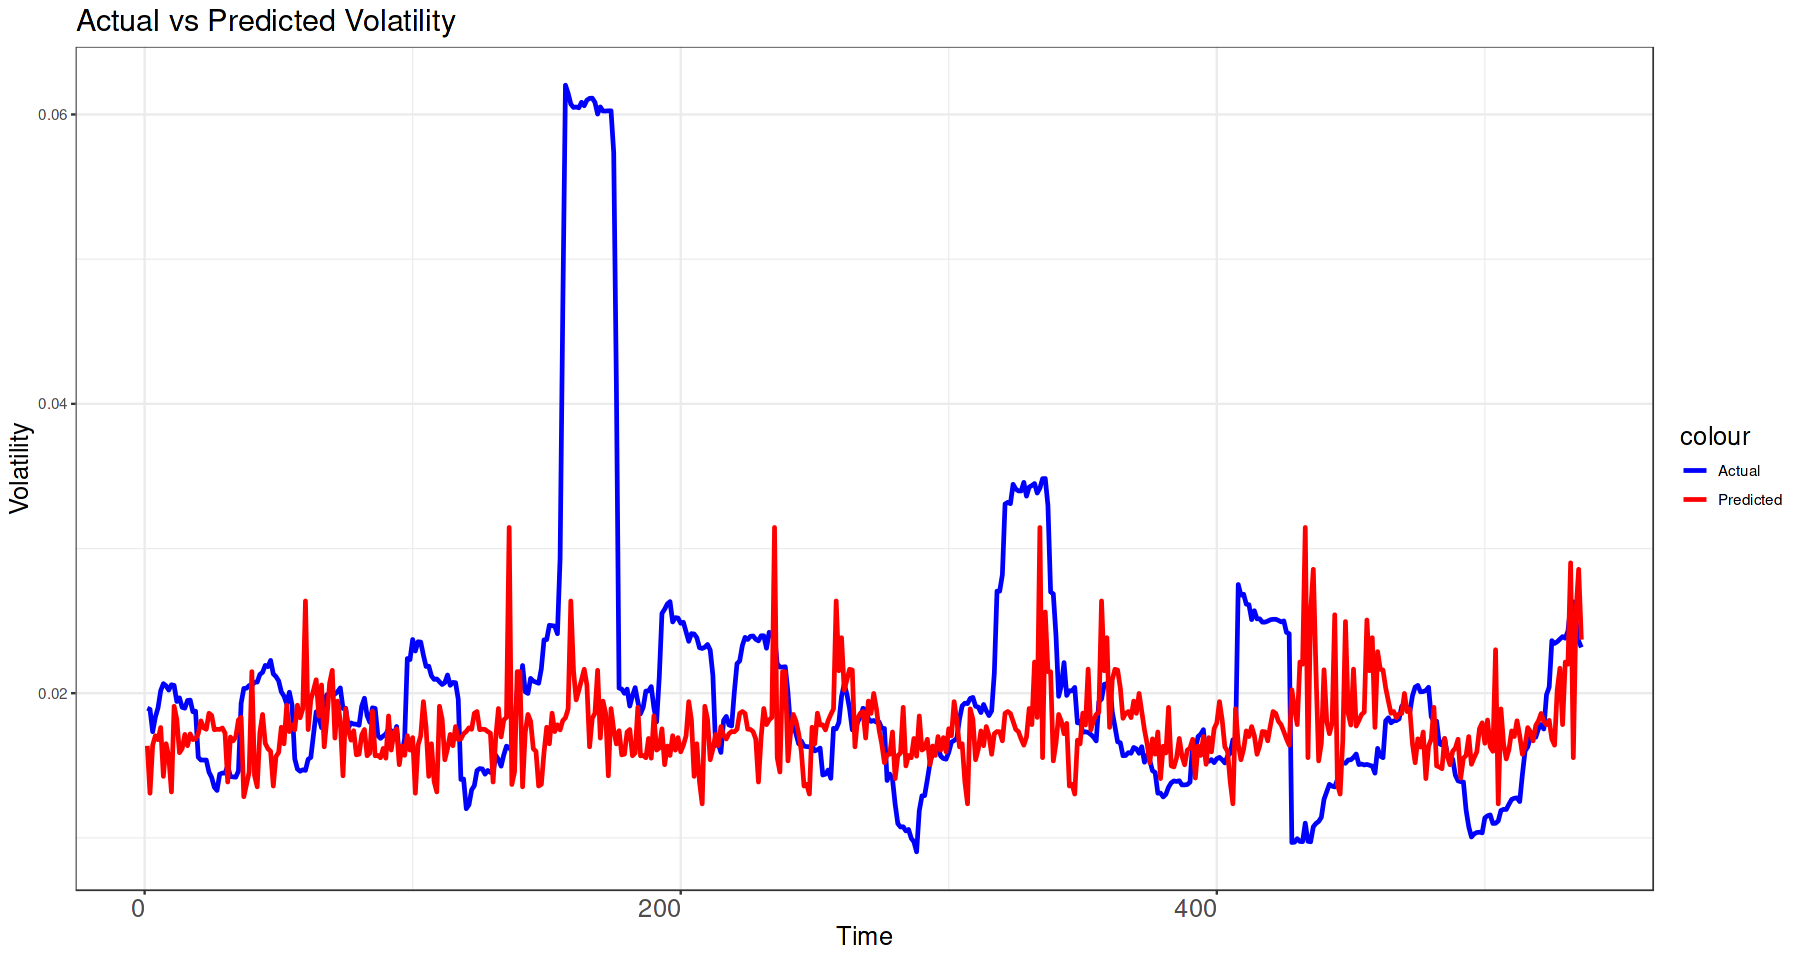

In [289]:
plot_df <- data.frame(
  idx = 1:length(actual_vol),
  actual = actual_vol,
  pred = pred_vol
)

ggplot(plot_df, aes(x = idx)) +
  geom_line(aes(y = actual, color = "Actual"), linewidth = 1) +
  geom_line(aes(y = pred, color = "Predicted"), linewidth = 1) +
  labs(title = "Actual vs Predicted Volatility", x = "Time", y = "Volatility") +
  scale_color_manual(values = c("Actual" = "blue", "Predicted" = "red"))+ 
       theme_bw() +
        theme(
        axis.title = element_text(size=10),
        axis.text.x = element_text(size = 15, hjust=1),
        title = element_text(size=15),
        axis.title.x = element_text(size = 15),
        axis.title.y = element_text(size = 15)
              )

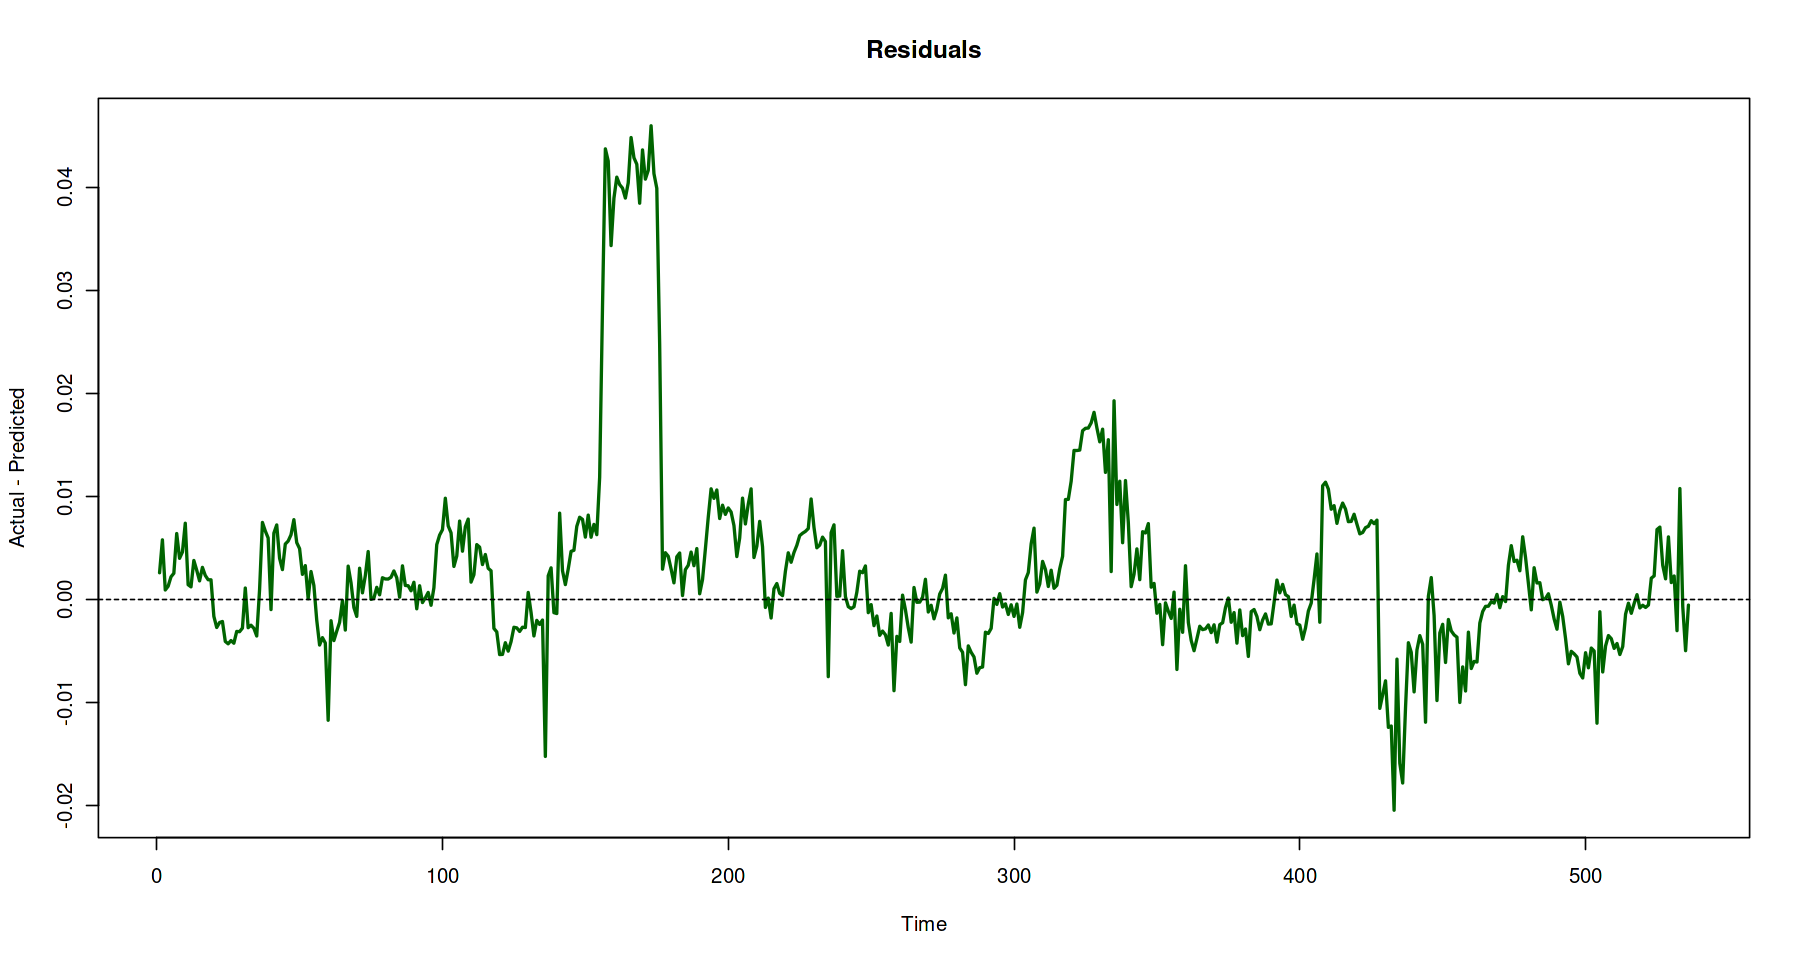

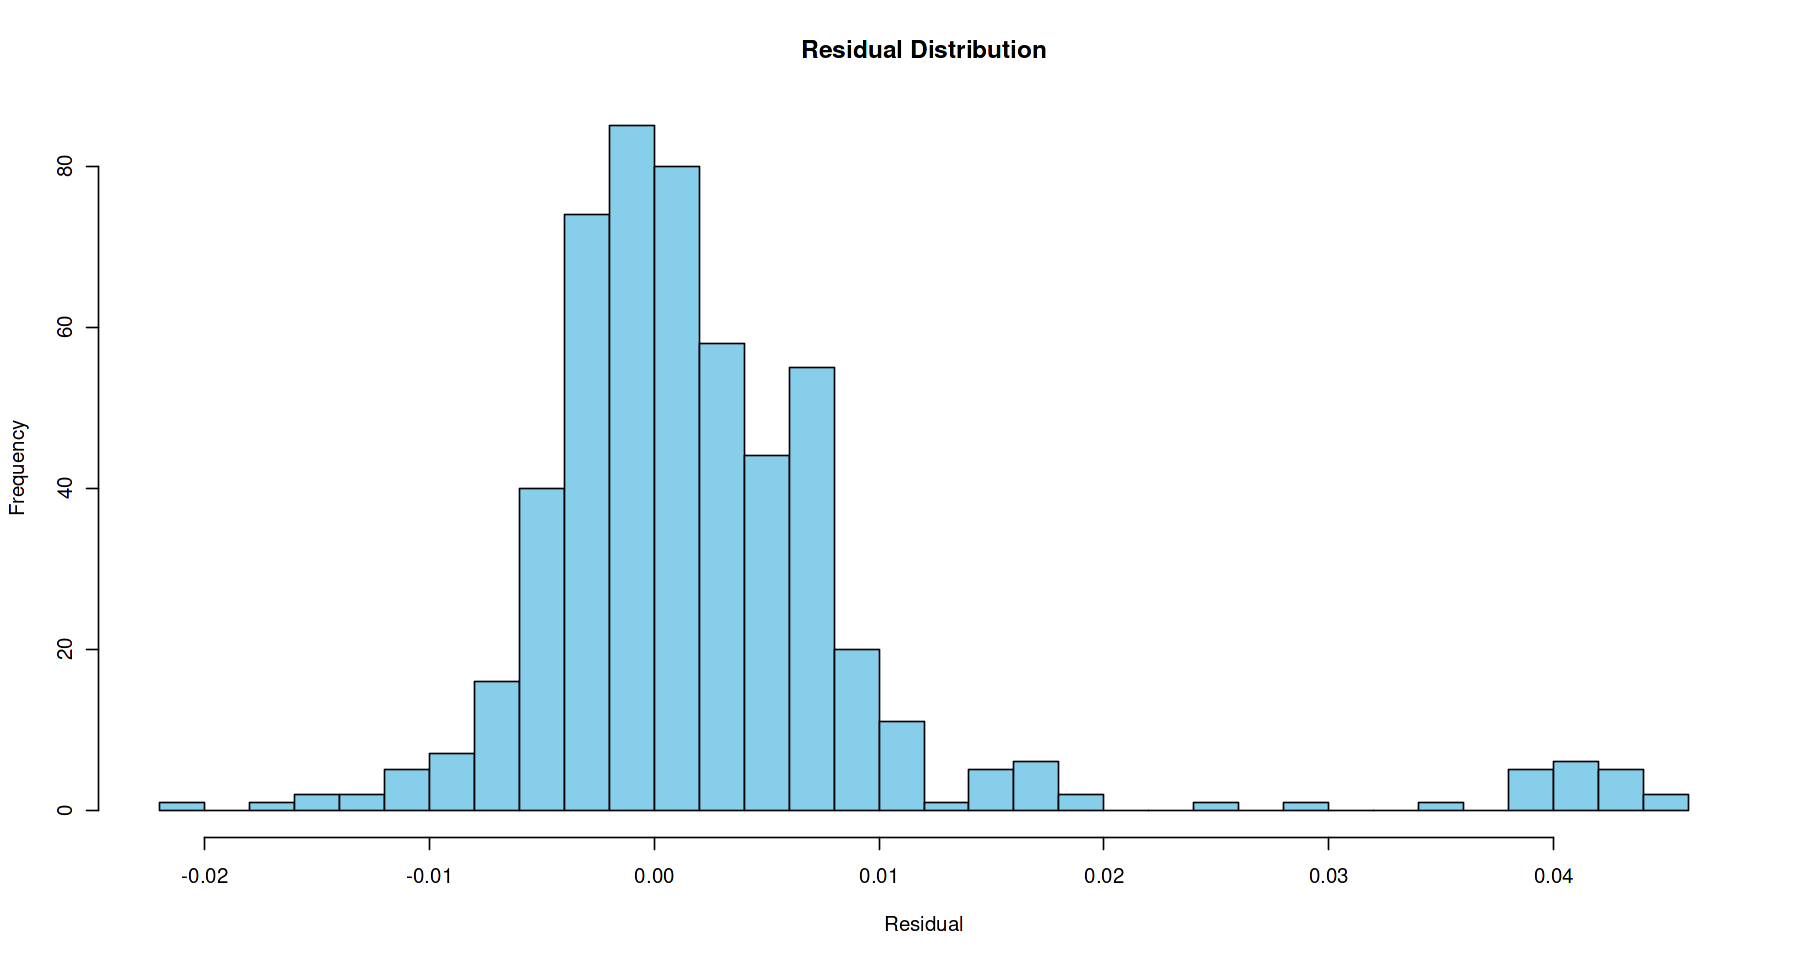

In [290]:
residual <- actual_vol - pred_vol
plot(residual, type = "l", col = "darkgreen", lwd = 2,
     main = "Residuals", ylab = "Actual - Predicted", xlab = "Time")
abline(h = 0, lty = 2)

hist(residual, breaks = 40, col = "skyblue",
     main = "Residual Distribution", xlab = "Residual")

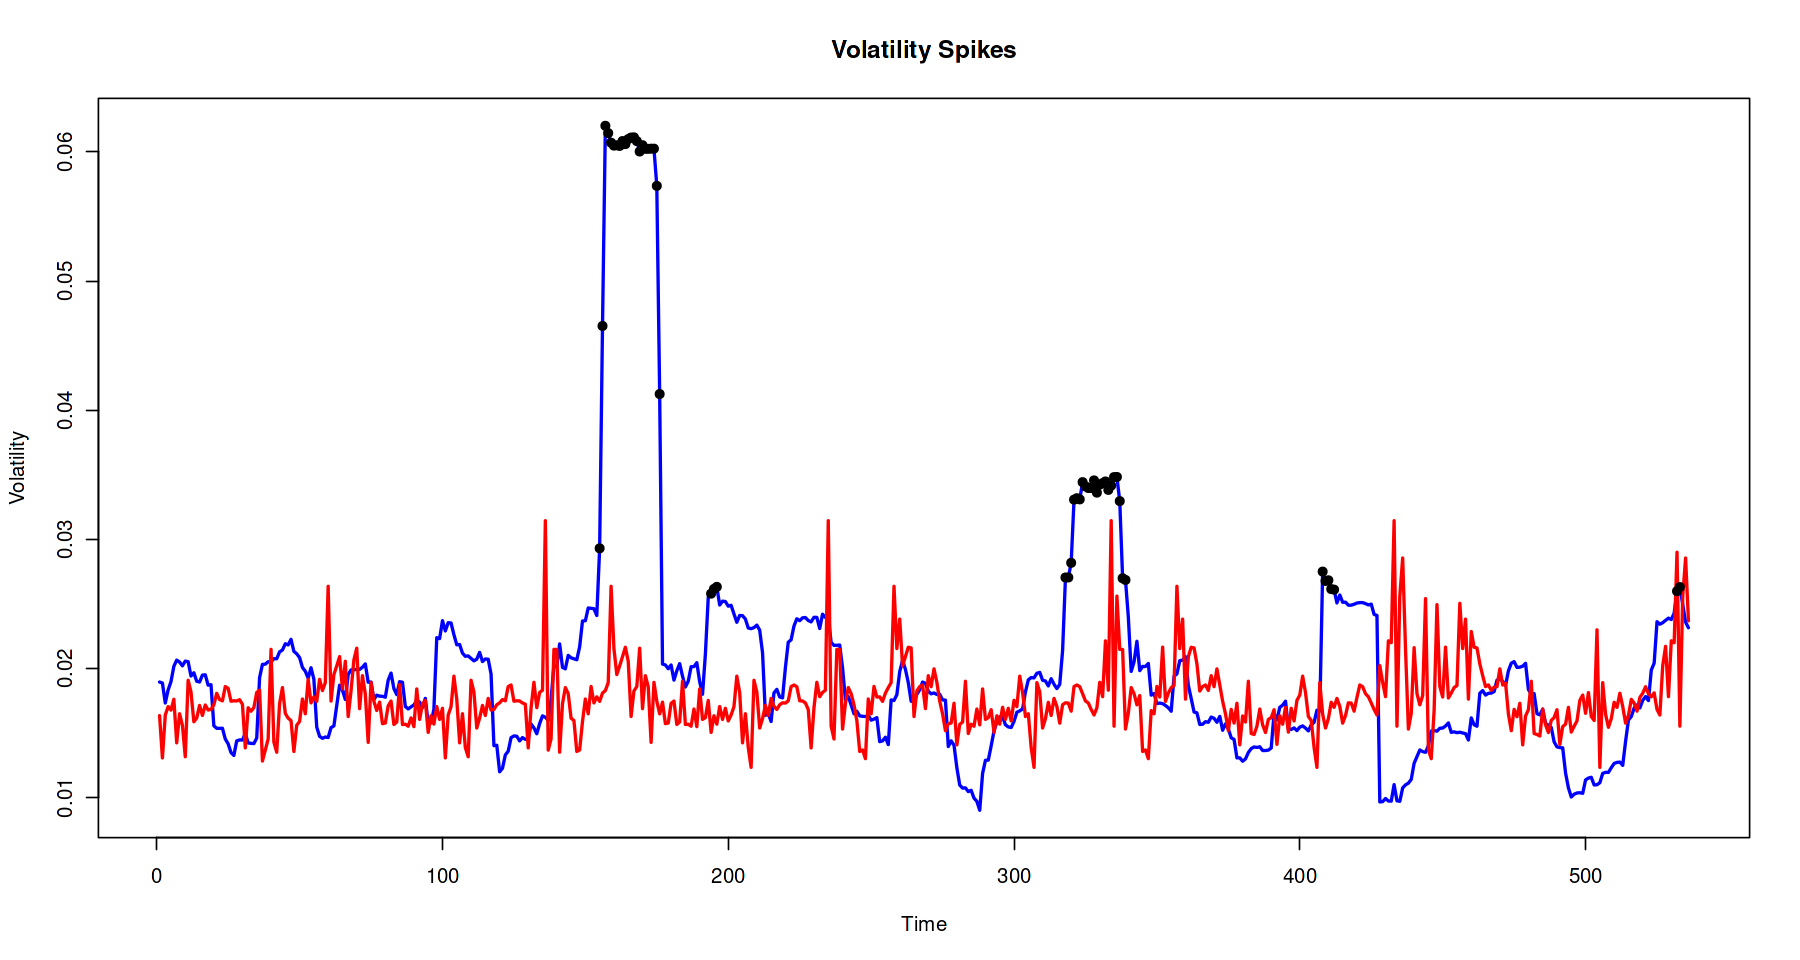

In [291]:
threshold <- quantile(actual_vol, 0.9, na.rm = TRUE)

spike_idx <- which(actual_vol >= threshold)

plot(actual_vol, type = "l", col = "blue", lwd = 2,
     main = "Volatility Spikes",
     ylab = "Volatility", xlab = "Time")
lines(pred_vol, col = "red", lwd = 2)
points(spike_idx, actual_vol[spike_idx], col = "black", pch = 16)

In [292]:
actual_diff <- diff(actual_vol)
pred_diff   <- diff(pred_vol)

direction_acc <- mean(sign(actual_diff) == sign(pred_diff), na.rm = TRUE)
cat("Direction Accuracy:", direction_acc, "\n")

Direction Accuracy: 0.517757 


### 📌**Result**   

**The LSTM-based volatility prediction model estimated the average level of volatility stably, but did not sufficiently capture the sudden increase in volatility.**    
**This is because the regression-based model tends to converge to the mean due to the abnormality and extreme value characteristics of the financial time series, and it was confirmed that the approach to classifying the high volatility section is more appropriate for risk detection.**

----------------
Please leave your advice in the comments. Thank you